# Tech Challenge Fase 3 - Previsão de Casos de Dengue

## 📋 Notebook 1: Definição do Problema e Coleta de Dados

### 📌 Objetivo
Este notebook aborda as primeiras etapas do Tech Challenge:
1. **Definição do problema**: Regressão para prever casos de dengue
2. **Coleta de dados**: Análise inicial do dataset disponível
3. **Armazenamento**: Dataset estruturado em formato CSV

### 🎯 Problema de Negócio
Prever o número de casos de dengue por município utilizando dados climáticos e de saneamento para auxiliar na gestão de saúde pública e alocação de recursos.

**Tipo do Problema:** Regressão (prever valores numéricos contínuos)

In [2]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurações para visualização
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 📊 Carregamento e Análise Inicial dos Dados

In [2]:
# Carregamento do dataset
df = pd.read_csv('../data/raw/dados_dengue_clima_saneamento_2014_2025.csv')

# Extrair ano e mês da coluna periodo
df['data'] = pd.to_datetime(df['periodo'])
df['Ano'] = df['data'].dt.year
df['Mês'] = df['data'].dt.month

print(f"📋 Informações básicas do dataset:")
print(f"   • Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"   • Período: {df['Ano'].min()} - {df['Ano'].max()}")
print(f"   • Estados (COD_UF): {df['COD_UF'].nunique()} únicos")
print(f"   • Total de casos no período: {df['Quantidade de Casos'].sum():,}")

# Visualização das primeiras linhas
print("\n📄 Primeiras 5 linhas do dataset:")
df.head()

📋 Informações básicas do dataset:
   • Dimensões: 3584 linhas x 23 colunas
   • Período: 2014 - 2025
   • Estados (COD_UF): 27 únicos
   • Total de casos no período: 21,136,450

📄 Primeiras 5 linhas do dataset:


,Quantidade de Casos,COD_UF,periodo,precipitacao_media_mensal_uf,temp_max_media_mensal_uf,temp_min_media_mensal_uf,umidade_max_media_mensal_uf,umidade_min_media_mensal_uf,pressao_max_media_mensal_uf,pressao_min_media_mensal_uf,...,Número de pessoas por moradia (pessoas por moradia) (IBGE),Número de pessoas por moradia (área urbana) (pessoas por moradia) (IBGE),Parcela da população total que mora em domicílios sem acesso ao serviço de coleta de esgoto (% da população) (SINISA),Parcela da população total que mora em domicílios sem acesso à água tratada (% da população) (SINISA),População total (pessoas) (IBGE),População urbana total (pessoas) (SINISA),Taxa de incidência de internações por doenças associadas à falta de saneamento (Internações por 10 mil habitantes) (DATASUS),data,Ano,Mês
0,521,AC,2014-01,306.200000,26.168398,25.172873,86.335013,80.105127,988.055018,987.365278,...,3.65,3.49,8.8,55.4,790101.0,572554.0,43.779,2014-01-01,2014,1
1,860,AL,2014-01,31.033333,27.146483,25.862634,73.222670,67.688172,1000.114113,999.650627,...,3.39,3.13,77.7,22.1,3321730.0,2316270.0,21.522,2014-01-01,2014,1
2,1537,AM,2014-01,243.305882,26.704184,25.695380,84.414789,79.235912,1003.842685,1003.189520,...,4.06,3.18,9.3,26.1,3873743.0,2540454.0,14.159,2014-01-01,2014,1
3,34,AP,2014-01,320.200000,25.811156,24.882997,87.120968,84.208333,1010.215188,1009.659610,...,4.03,4.02,96.1,65.6,750912.0,672809.0,1.373,2014-01-01,2014,1
4,1429,BA,2014-01,48.005405,26.084308,24.723933,73.336720,66.922169,970.333907,969.846090,...,3.23,0.31,67.2,21.4,15126371.0,10770479.0,28.676,2014-01-01,2014,1


In [3]:
# Análise dos tipos de dados e valores ausentes
print("🔍 Informações sobre o dataset:")
print(df.info())

print("\n📊 Estatísticas descritivas da variável alvo:")
print(df['Quantidade de Casos'].describe())

print("\n❌ Valores ausentes por coluna:")
missing_values = df.isnull().sum()
if missing_values.sum() > 0:
    print(missing_values[missing_values > 0])
else:
    print("✅ Não há valores ausentes no dataset!")

🔍 Informações sobre o dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3584 entries, 0 to 3583
Data columns (total 23 columns):
 #   Column                                                                                                                                                 Non-Null Count  Dtype         
---  ------                                                                                                                                                 --------------  -----         
 0   Quantidade de Casos                                                                                                                                    3584 non-null   int64         
 1   COD_UF                                                                                                                                                 3584 non-null   object        
 2   periodo                                                                                                      

## 📈 Análise Exploratória dos Dados

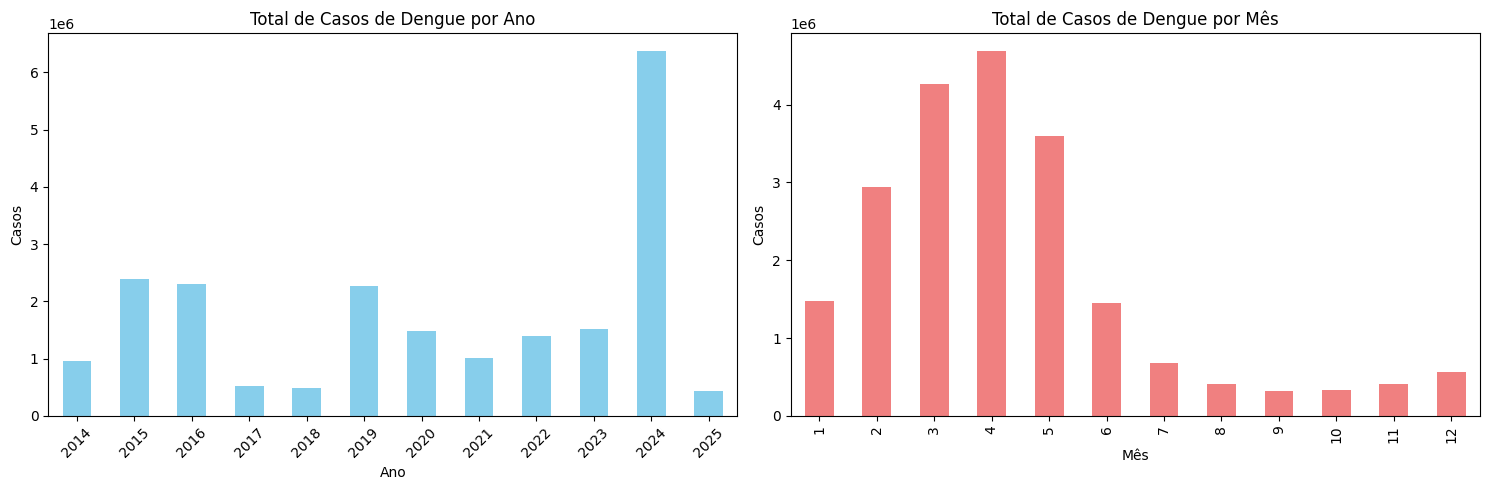

📊 Anos com maior número de casos:
Ano
2024    6369884
2015    2394479
2016    2303895
Name: Quantidade de Casos, dtype: int64


In [4]:
# Análise temporal dos casos de dengue
plt.figure(figsize=(15, 5))

# Agregação por ano
casos_por_ano = df.groupby('Ano')['Quantidade de Casos'].sum()
plt.subplot(1, 2, 1)
casos_por_ano.plot(kind='bar', color='skyblue')
plt.title('Total de Casos de Dengue por Ano')
plt.xlabel('Ano')
plt.ylabel('Casos')
plt.xticks(rotation=45)

# Agregação por mês
casos_por_mes = df.groupby('Mês')['Quantidade de Casos'].sum()
plt.subplot(1, 2, 2)
casos_por_mes.plot(kind='bar', color='lightcoral')
plt.title('Total de Casos de Dengue por Mês')
plt.xlabel('Mês')
plt.ylabel('Casos')

plt.tight_layout()
plt.show()

print(f"📊 Anos com maior número de casos:")
print(casos_por_ano.sort_values(ascending=False).head(3))

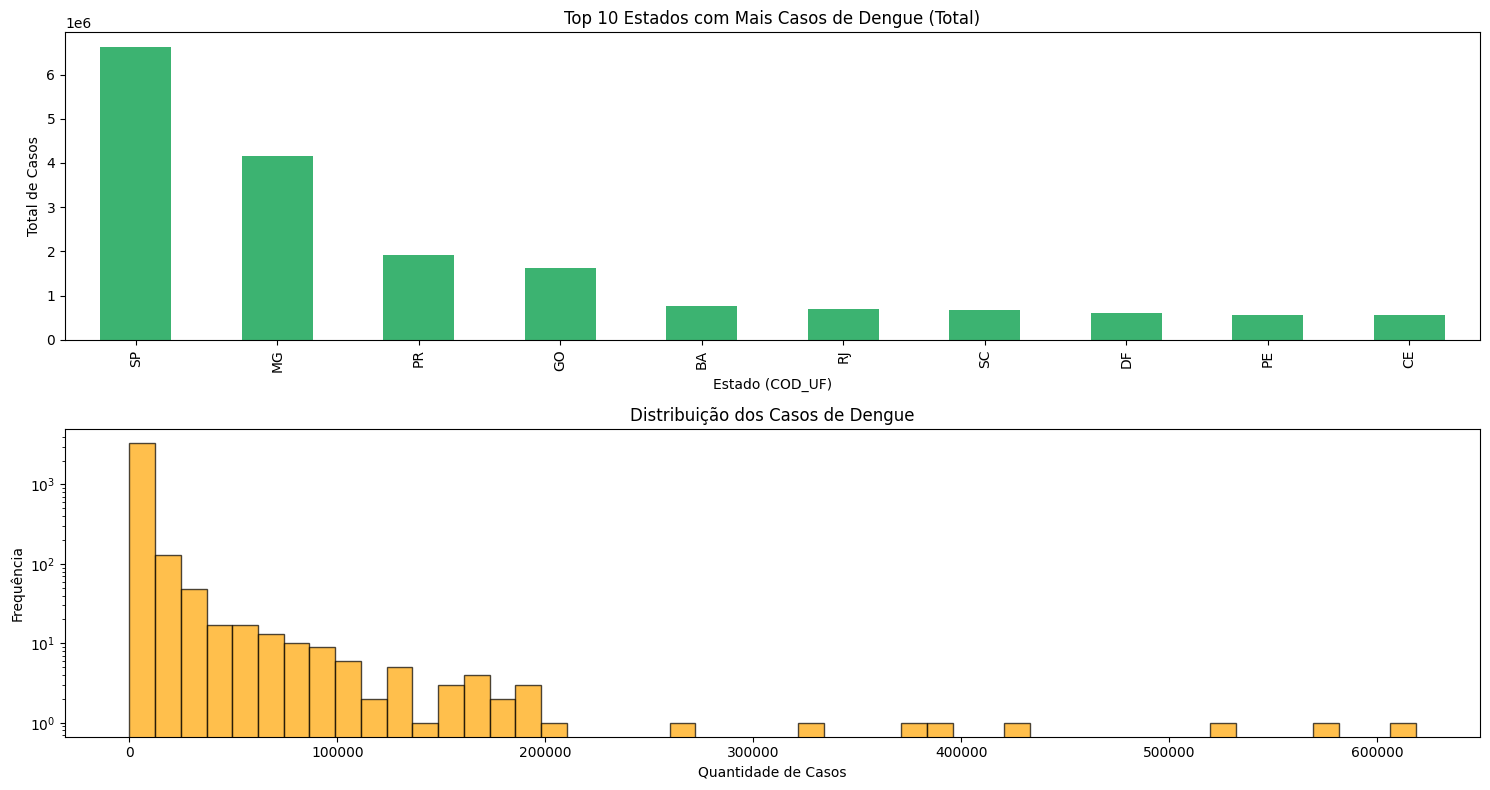

🏆 Ranking dos estados por casos:
   1º. SP: 6,623,734 casos
   2º. MG: 4,157,365 casos
   3º. PR: 1,928,220 casos
   4º. GO: 1,620,873 casos
   5º. BA: 766,365 casos


In [5]:
# Análise por estados
plt.figure(figsize=(15, 8))

# Top 10 estados com mais casos
casos_por_estado = df.groupby('COD_UF')['Quantidade de Casos'].sum().sort_values(ascending=False)
plt.subplot(2, 1, 1)
casos_por_estado.head(10).plot(kind='bar', color='mediumseagreen')
plt.title('Top 10 Estados com Mais Casos de Dengue (Total)')
plt.xlabel('Estado (COD_UF)')
plt.ylabel('Total de Casos')

# Distribuição dos casos
plt.subplot(2, 1, 2)
plt.hist(df['Quantidade de Casos'], bins=50, color='orange', alpha=0.7, edgecolor='black')
plt.title('Distribuição dos Casos de Dengue')
plt.xlabel('Quantidade de Casos')
plt.ylabel('Frequência')
plt.yscale('log')  # Escala logarítmica devido à variação

plt.tight_layout()
plt.show()

print(f"🏆 Ranking dos estados por casos:")
for i, (estado, casos) in enumerate(casos_por_estado.head(5).items(), 1):
    print(f"   {i}º. {estado}: {casos:,} casos")

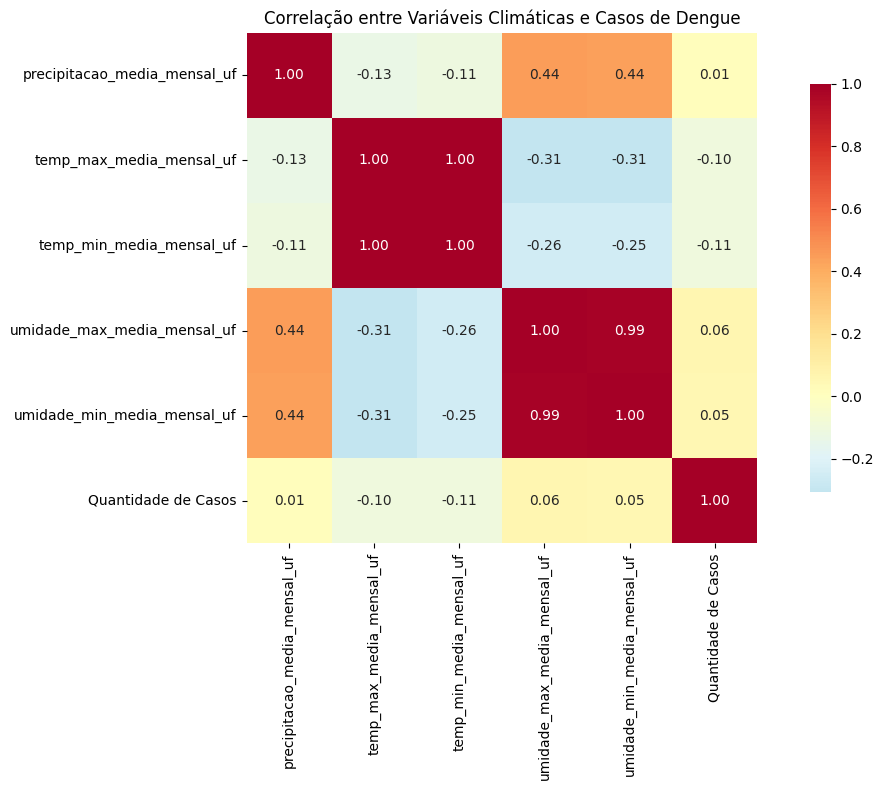

🌡️ Correlações com a quantidade de casos:
   • temp_min_media_mensal_uf: -0.105
   • temp_max_media_mensal_uf: -0.103
   • umidade_max_media_mensal_uf: 0.060
   • umidade_min_media_mensal_uf: 0.051
   • precipitacao_media_mensal_uf: 0.010


In [6]:
# Análise de correlação entre variáveis climáticas e casos de dengue
variaveis_climaticas = [
    'precipitacao_media_mensal_uf',
    'temp_max_media_mensal_uf',
    'temp_min_media_mensal_uf',
    'umidade_max_media_mensal_uf',
    'umidade_min_media_mensal_uf'
]

# Matriz de correlação
plt.figure(figsize=(12, 8))
correlacao = df[variaveis_climaticas + ['Quantidade de Casos']].corr()
sns.heatmap(correlacao, annot=True, cmap='RdYlBu_r', center=0,
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Correlação entre Variáveis Climáticas e Casos de Dengue')
plt.tight_layout()
plt.show()

print("🌡️ Correlações com a quantidade de casos:")
correlacoes_casos = correlacao['Quantidade de Casos'].drop('Quantidade de Casos').sort_values(key=abs, ascending=False)
for var, corr in correlacoes_casos.items():
    print(f"   • {var}: {corr:.3f}")

In [4]:
df_ts = pd.read_csv('../data/raw/dataset_serie_temporal.csv')

In [9]:
df_ts['ds'] = pd.to_datetime(df_ts['periodo'])
df_ts.drop(columns=['periodo'], inplace=True)

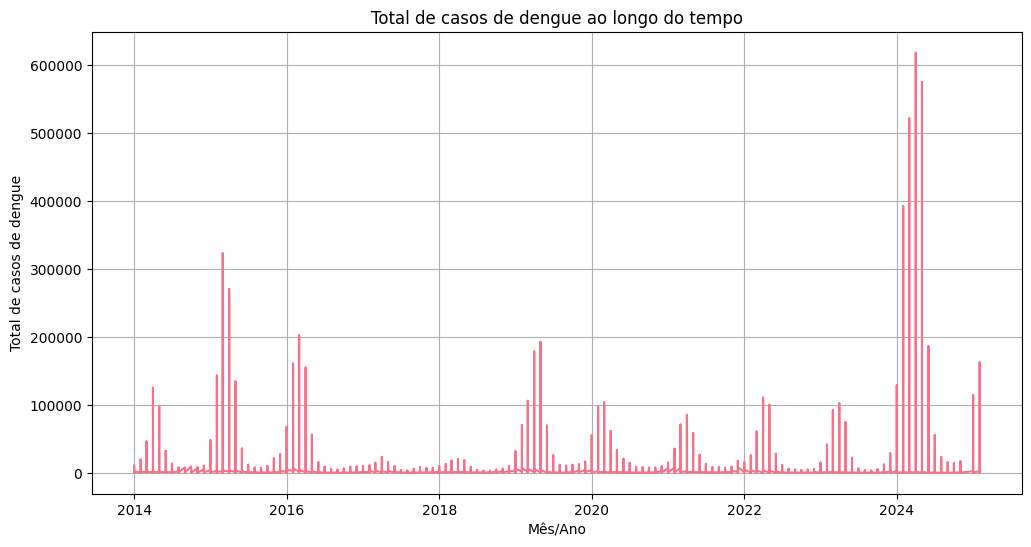

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(df_ts['ds'], df_ts['y'])
plt.xlabel('Mês/Ano')
plt.ylabel('Total de casos de dengue')
plt.title('Total de casos de dengue ao longo do tempo')
plt.grid(True)
plt.show()

In [11]:
ufs_unicas = df_ts['estado'].unique()

df_ts_por_estado = {}
for uf in ufs_unicas:
    df_ts_por_estado[uf] = df_ts[df_ts['estado'] == uf].drop(columns=['estado']).copy().reset_index(drop=True)

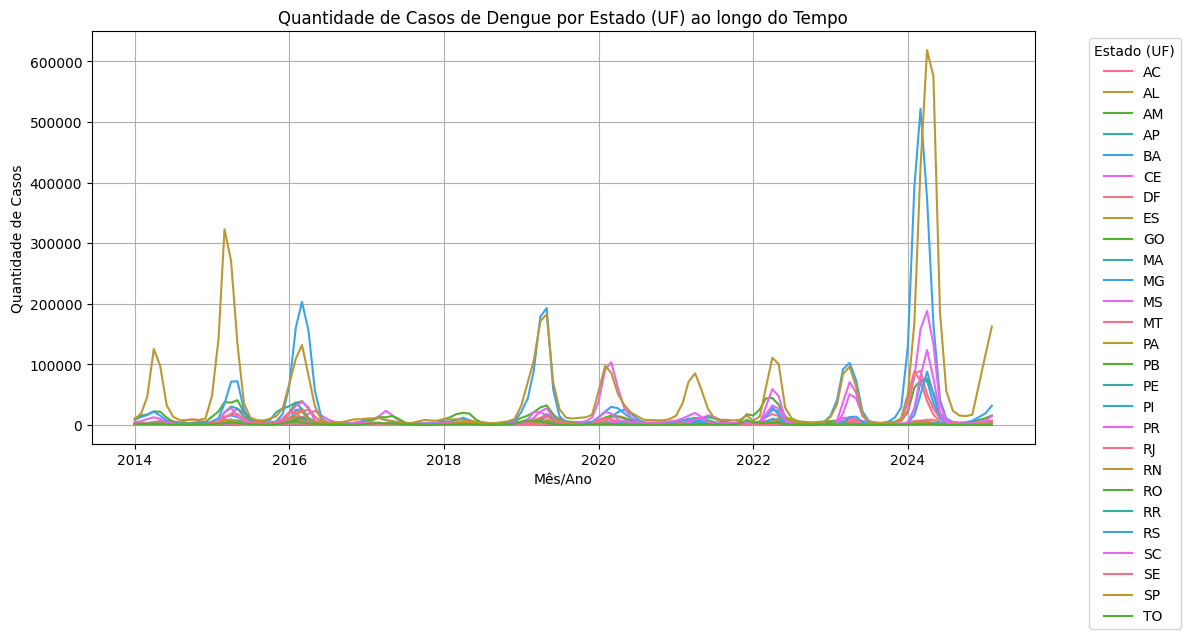

In [12]:
plt.figure(figsize=(12, 6))
for uf in ufs_unicas:
    df_uf = df_ts[df_ts['estado'] == uf].copy()
    plt.plot(df_uf['ds'], df_uf['y'], label=uf)

plt.xlabel('Mês/Ano')
plt.ylabel('Quantidade de Casos')
plt.title('Quantidade de Casos de Dengue por Estado (UF) ao longo do Tempo')
plt.legend(title='Estado (UF)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

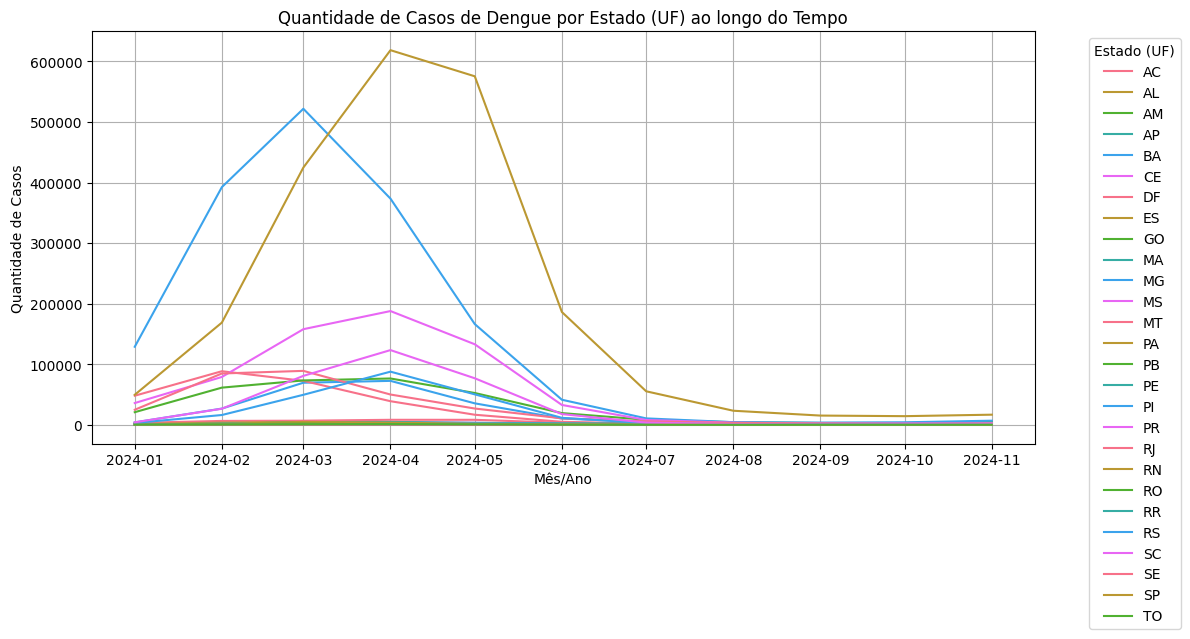

In [14]:
# Filtrar apenas o ano de 2024
df_ts_2024 = df_ts[df_ts['ds'].dt.year == 2024].copy()

for uf in ufs_unicas:
    df_uf = df_ts_2024[df_ts_2024['estado'] == uf].copy()
    plt.plot(df_uf['ds'], df_uf['y'], label=uf)

plt.xlabel('Mês/Ano')
plt.ylabel('Quantidade de Casos')
plt.title('Quantidade de Casos de Dengue por Estado (UF) ao longo do Tempo')
plt.legend(title='Estado (UF)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

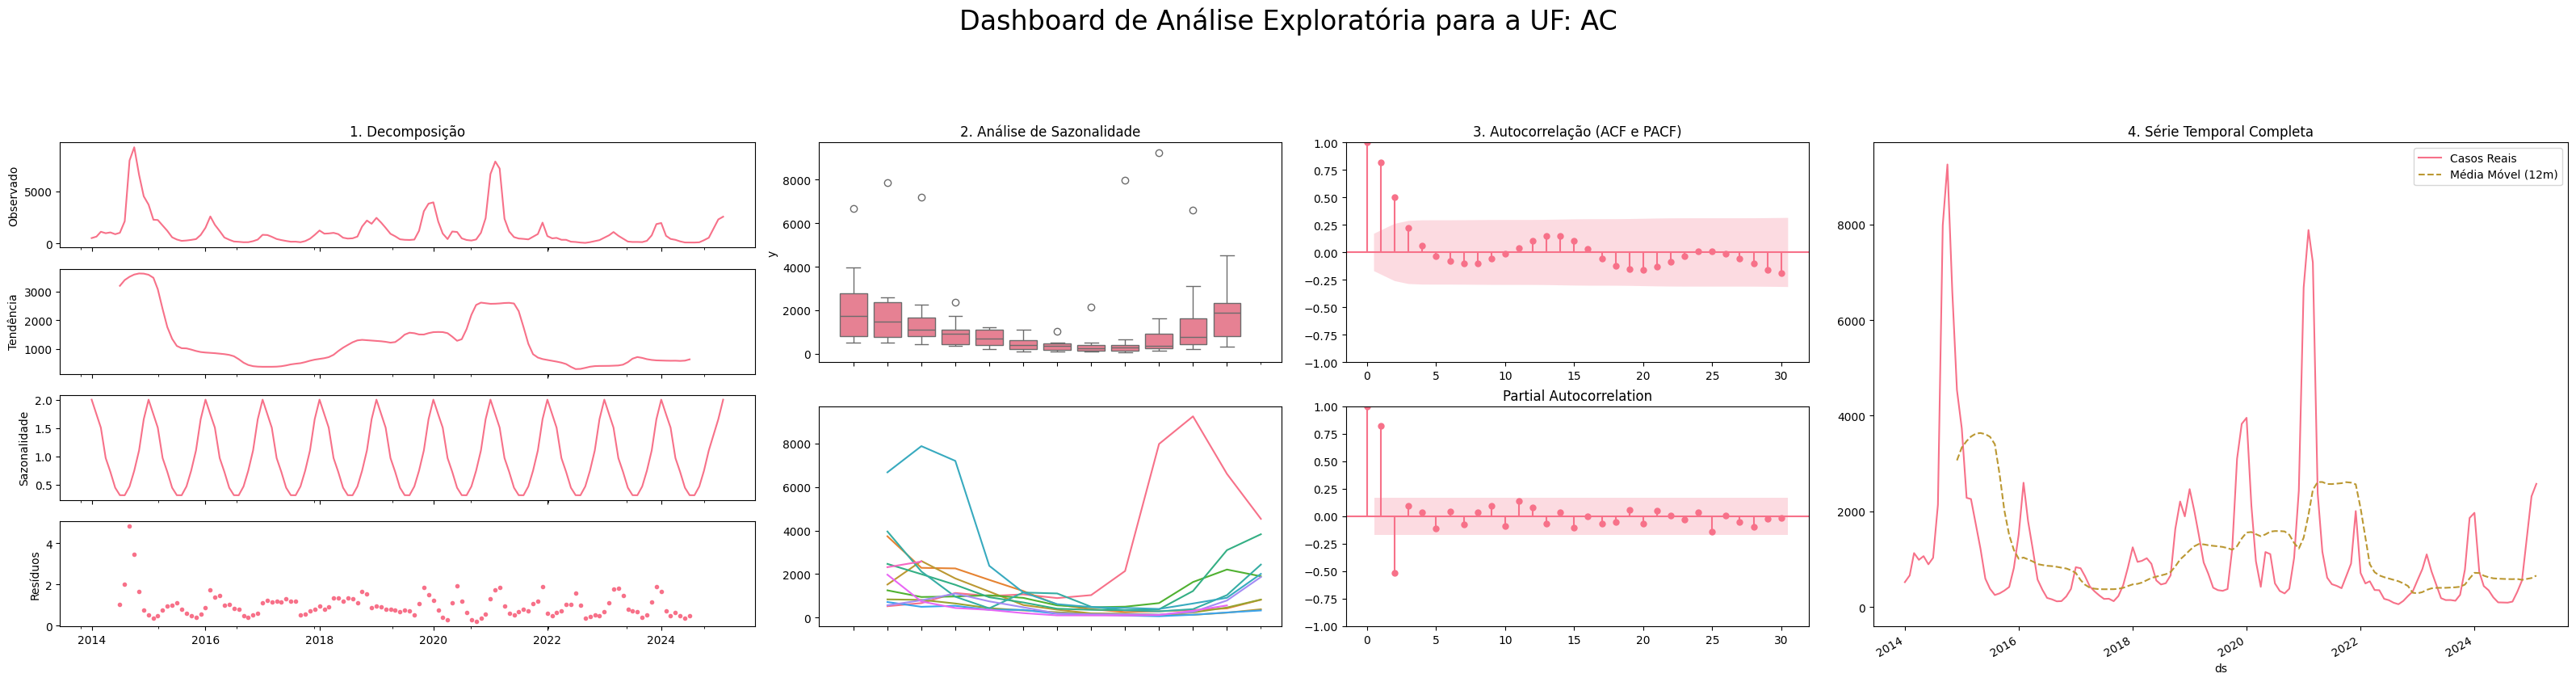

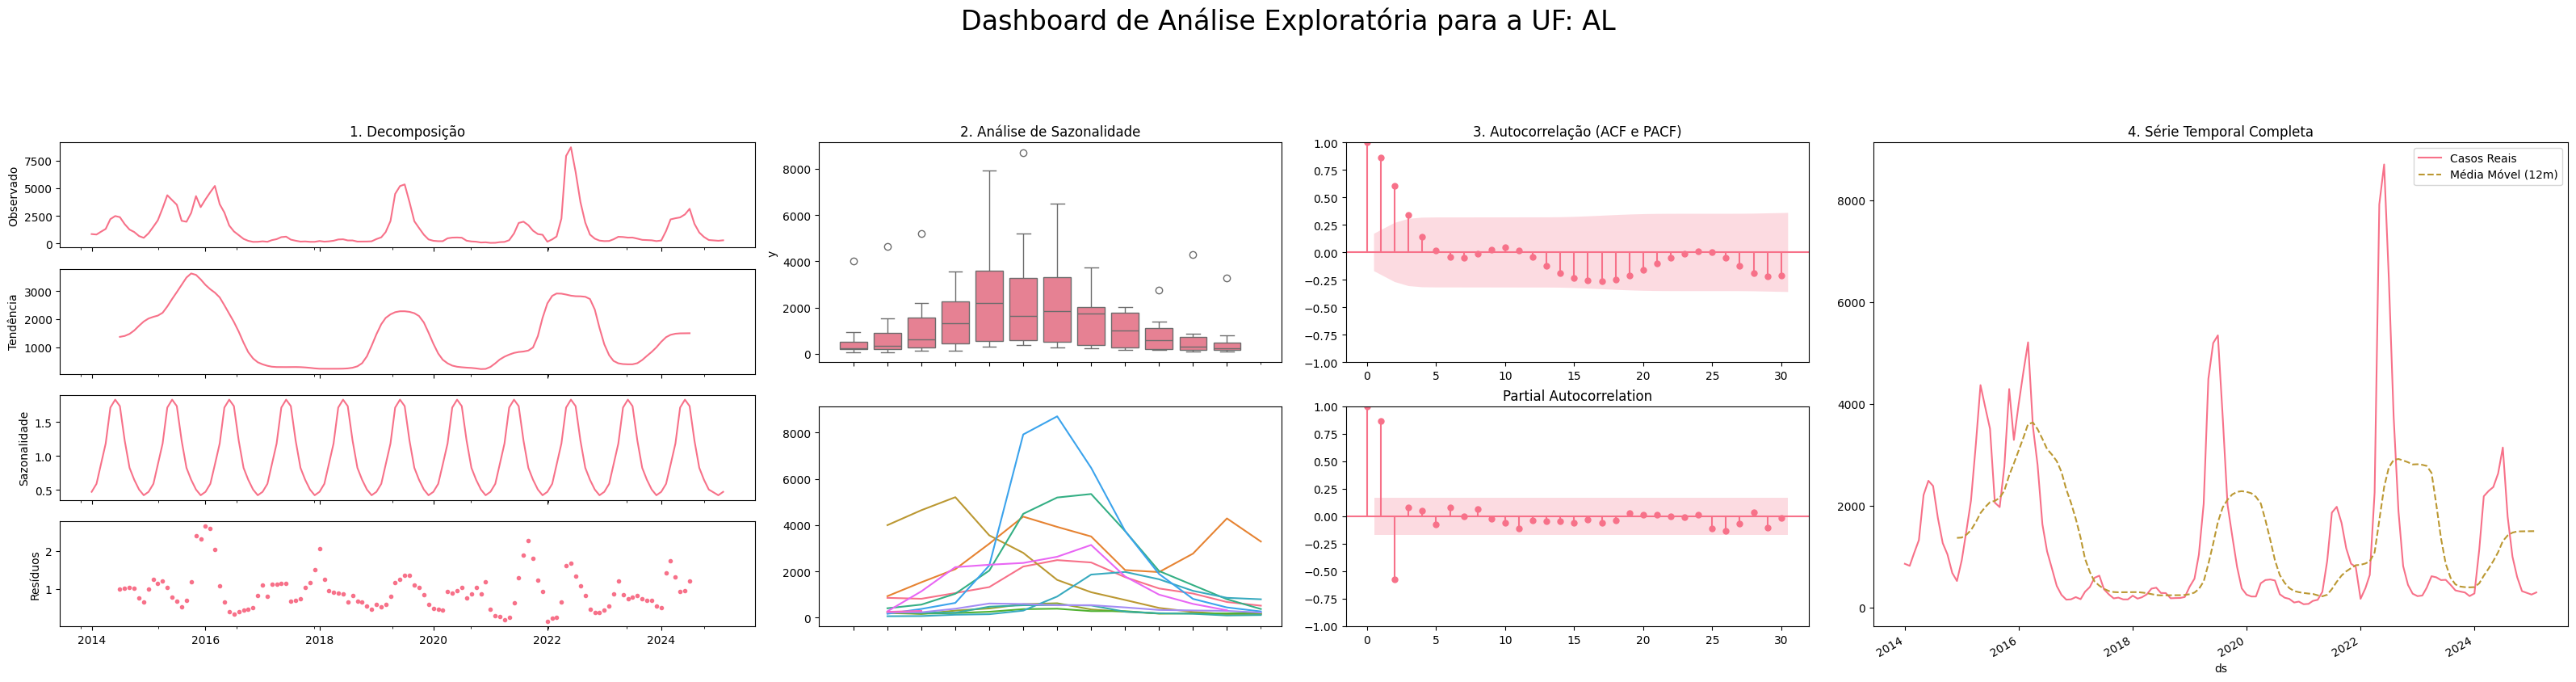

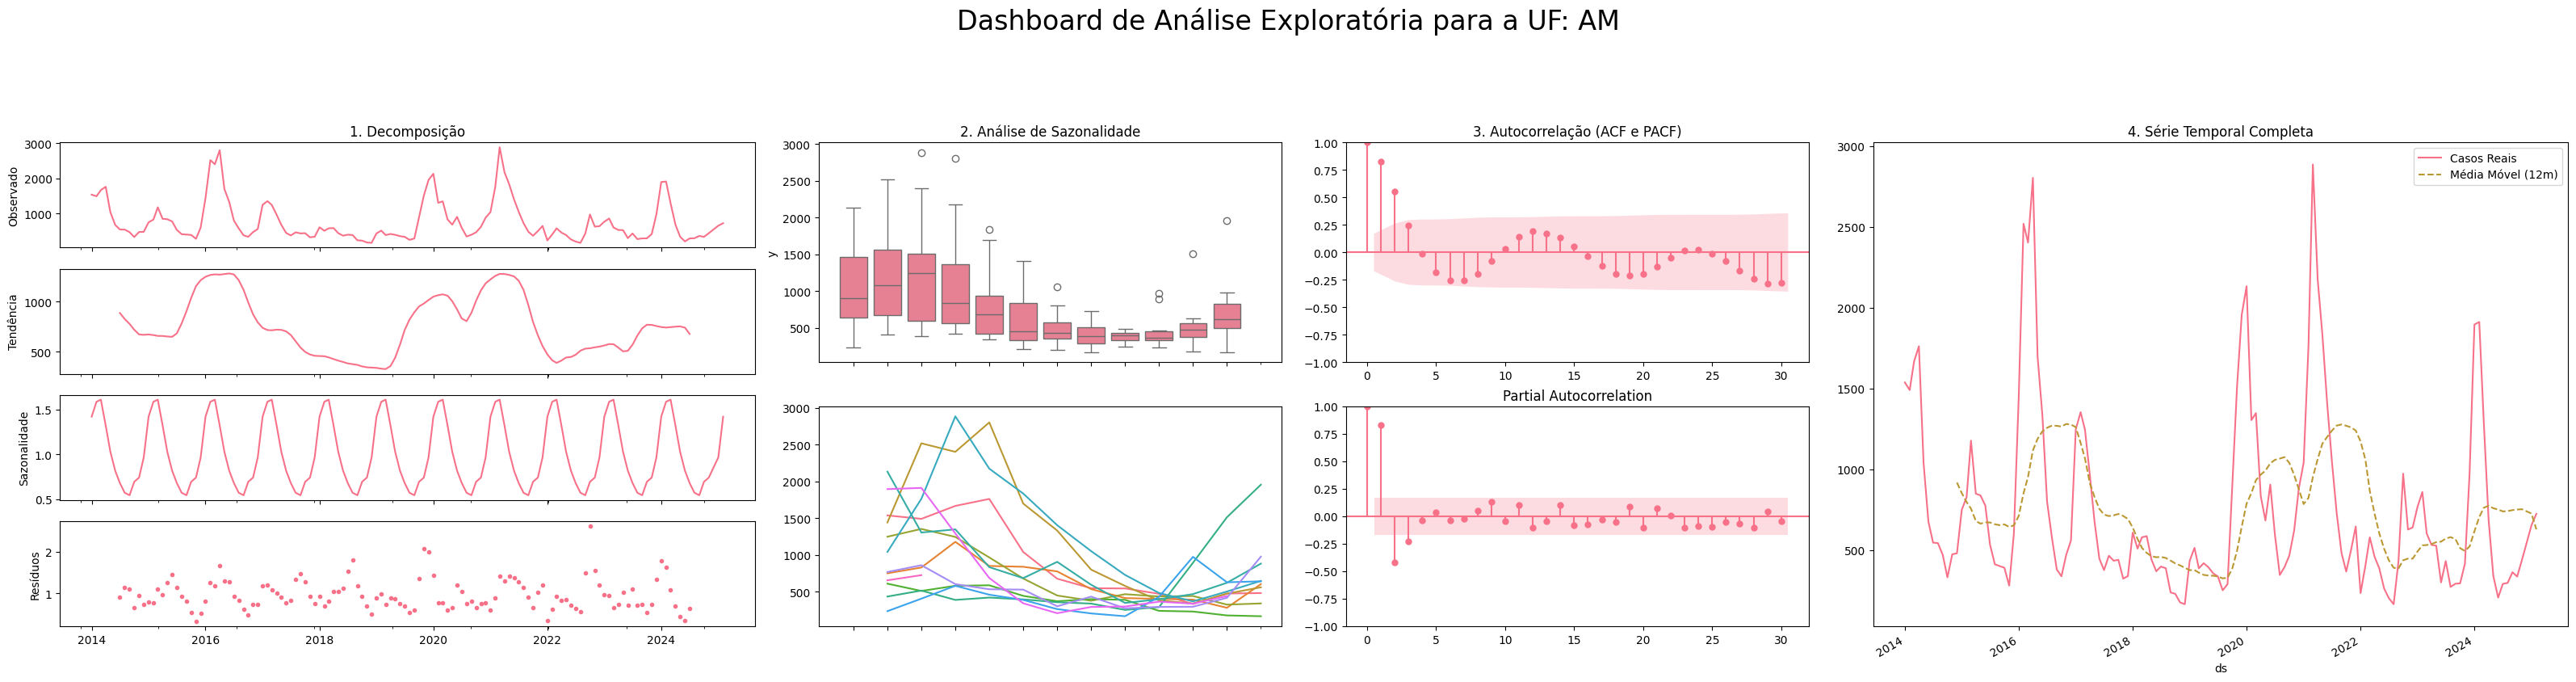

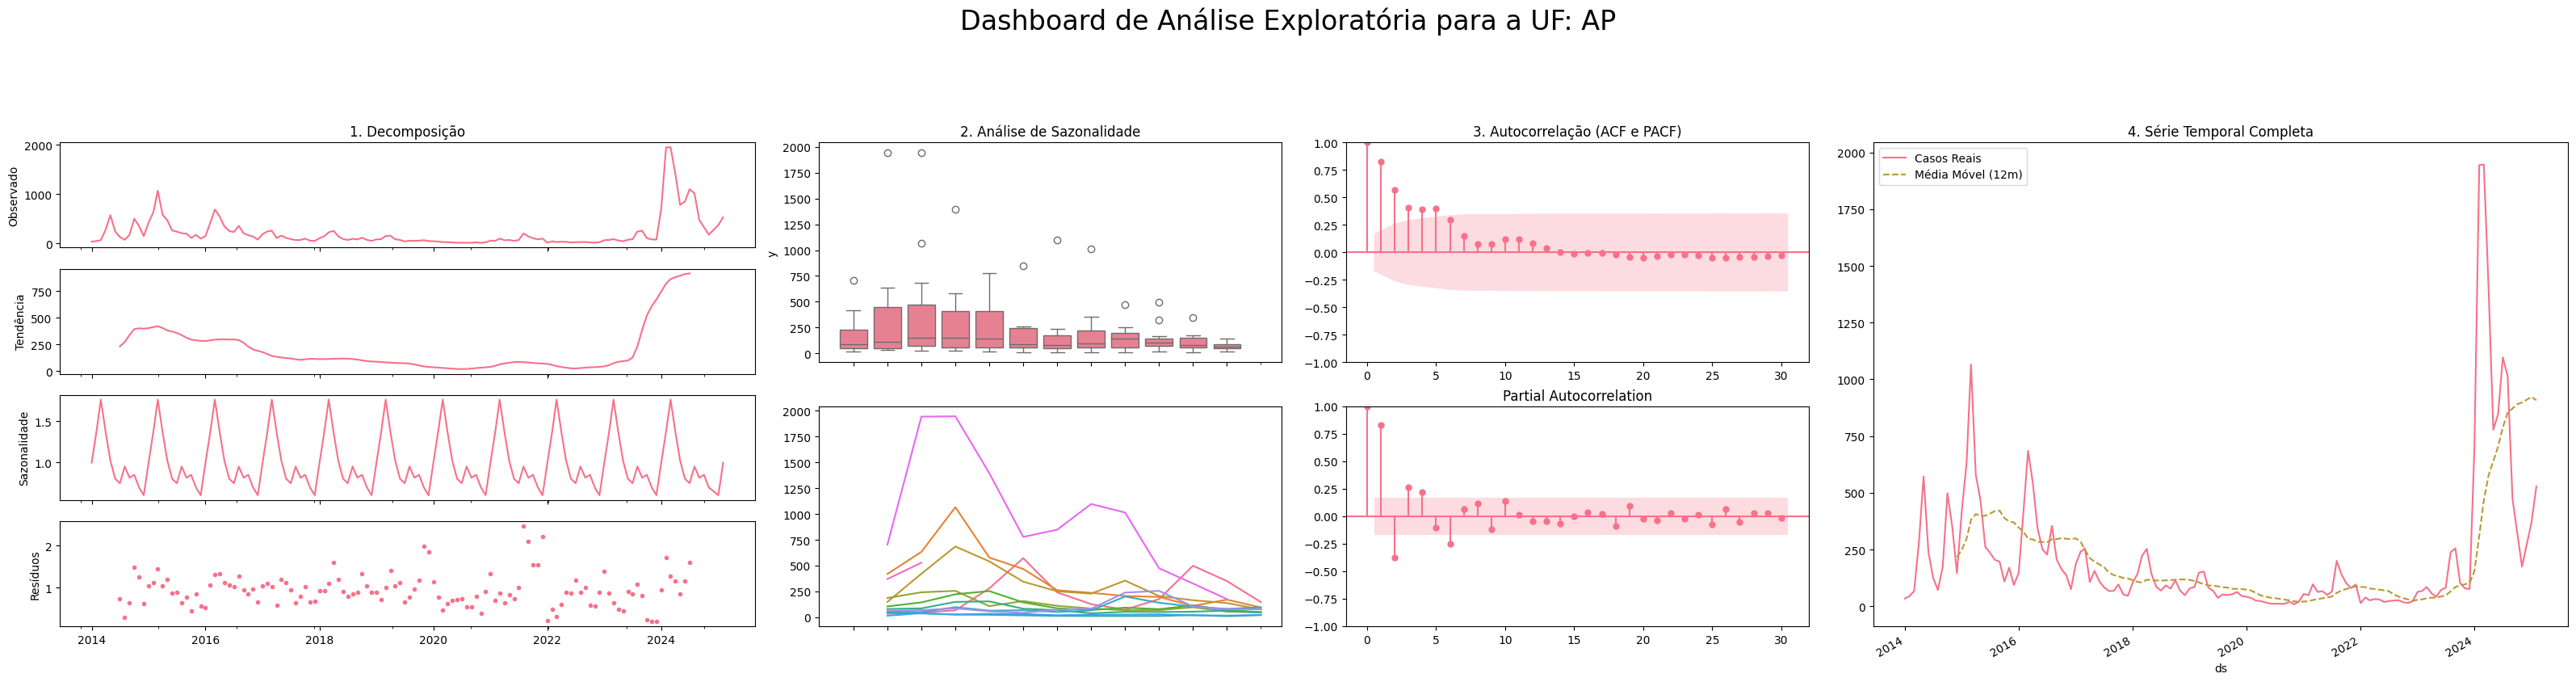

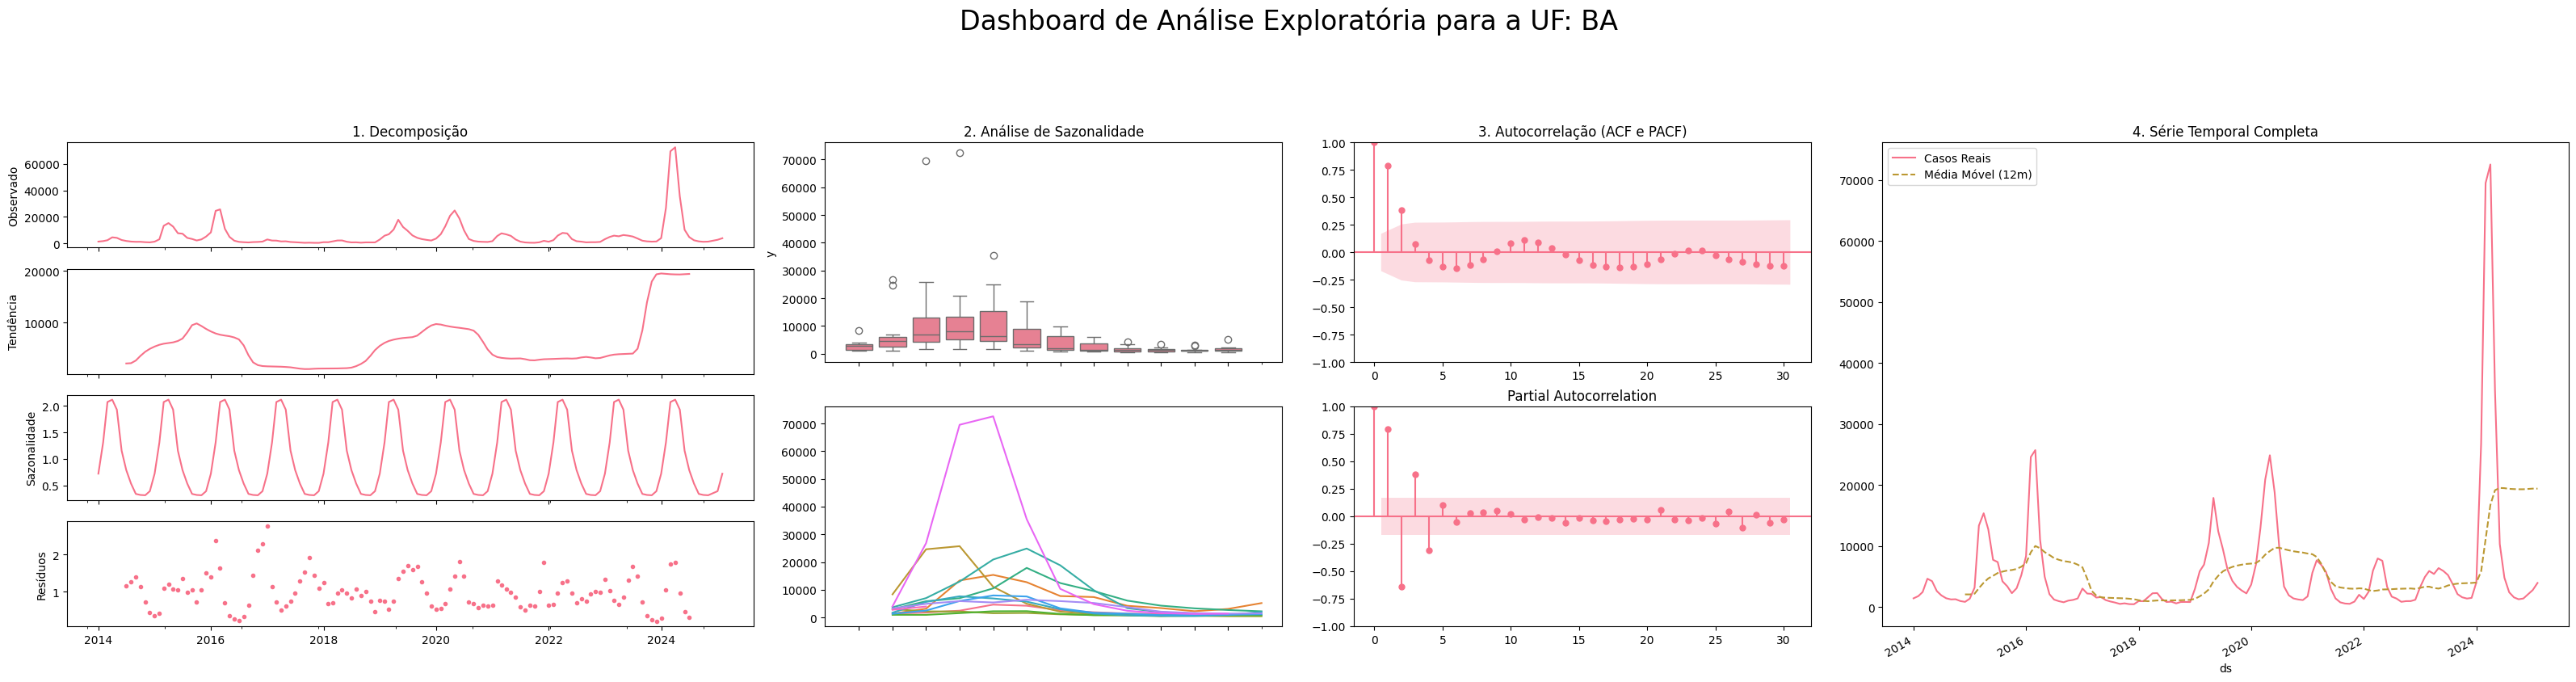

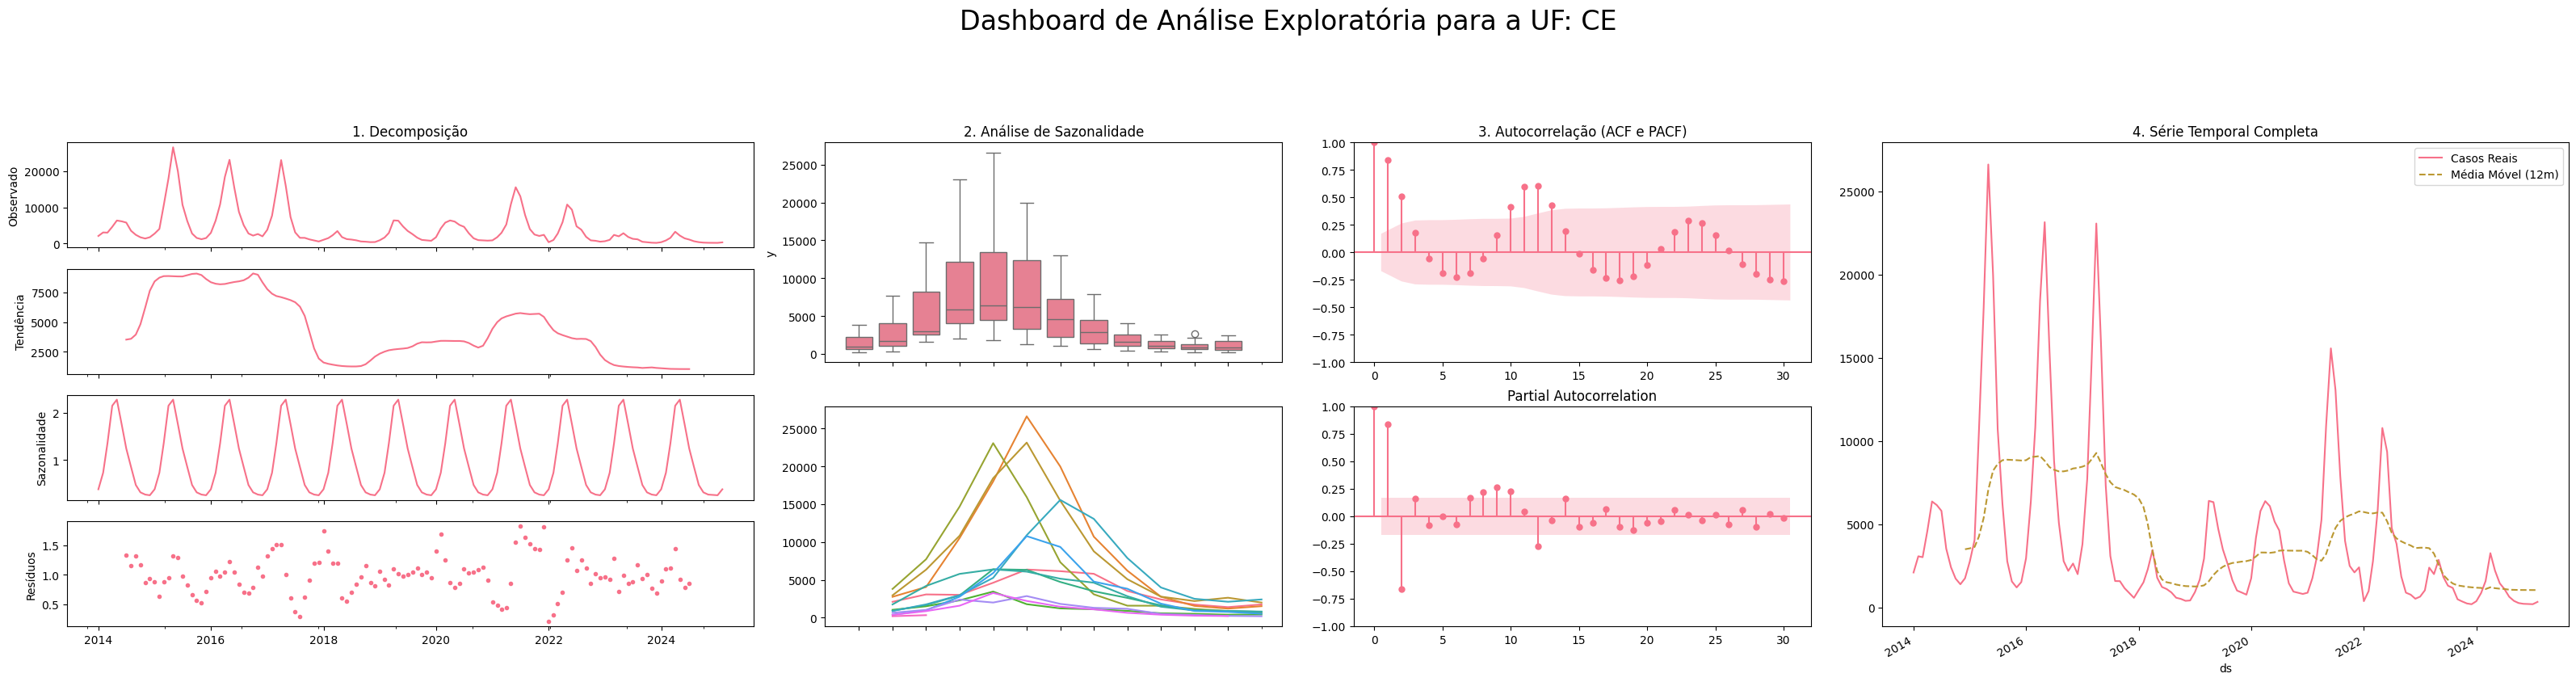

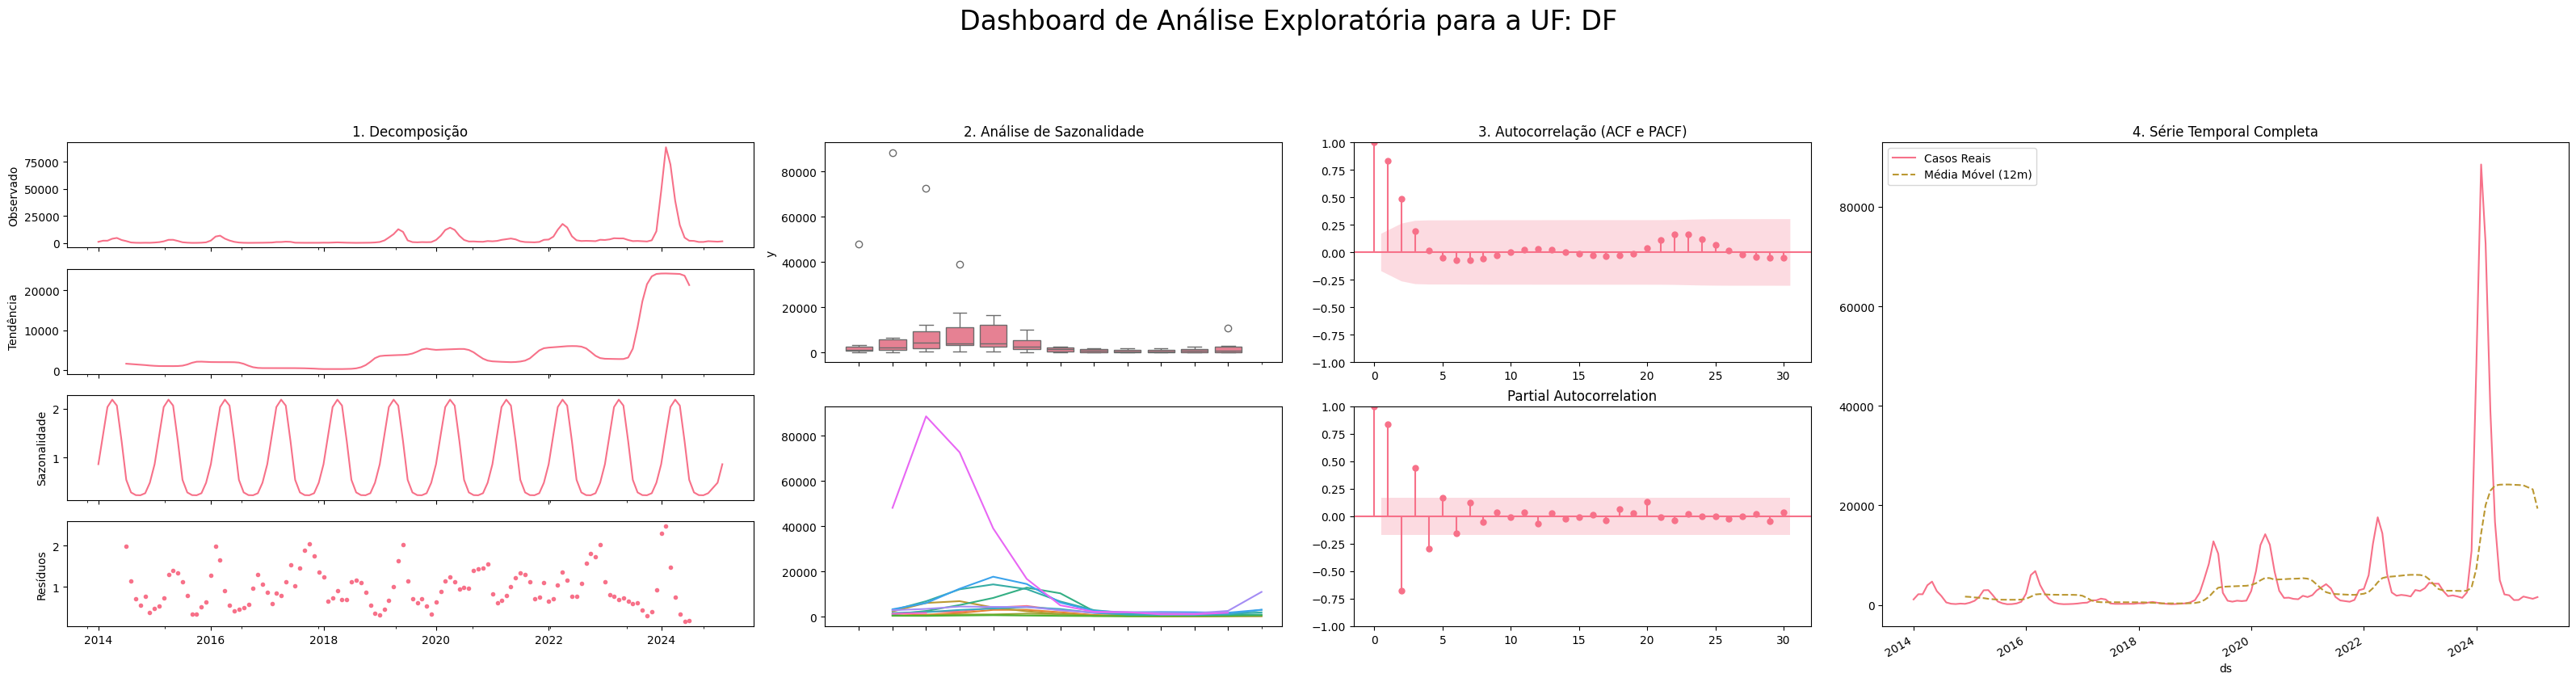

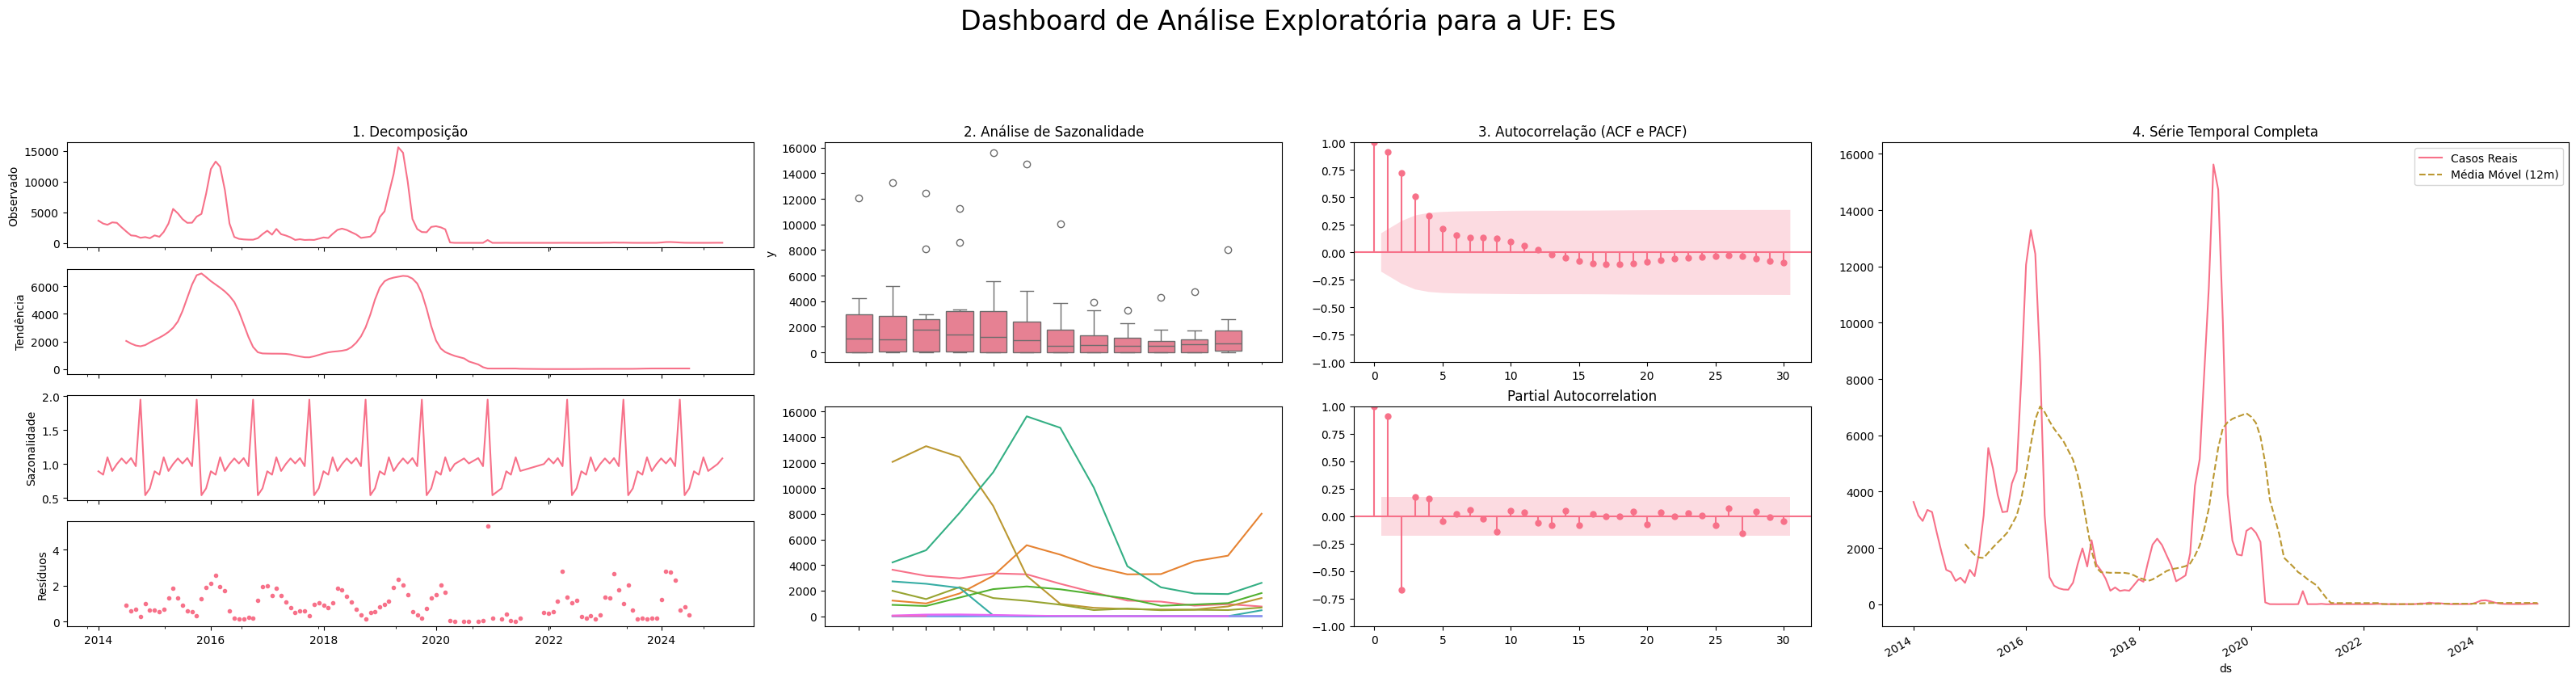

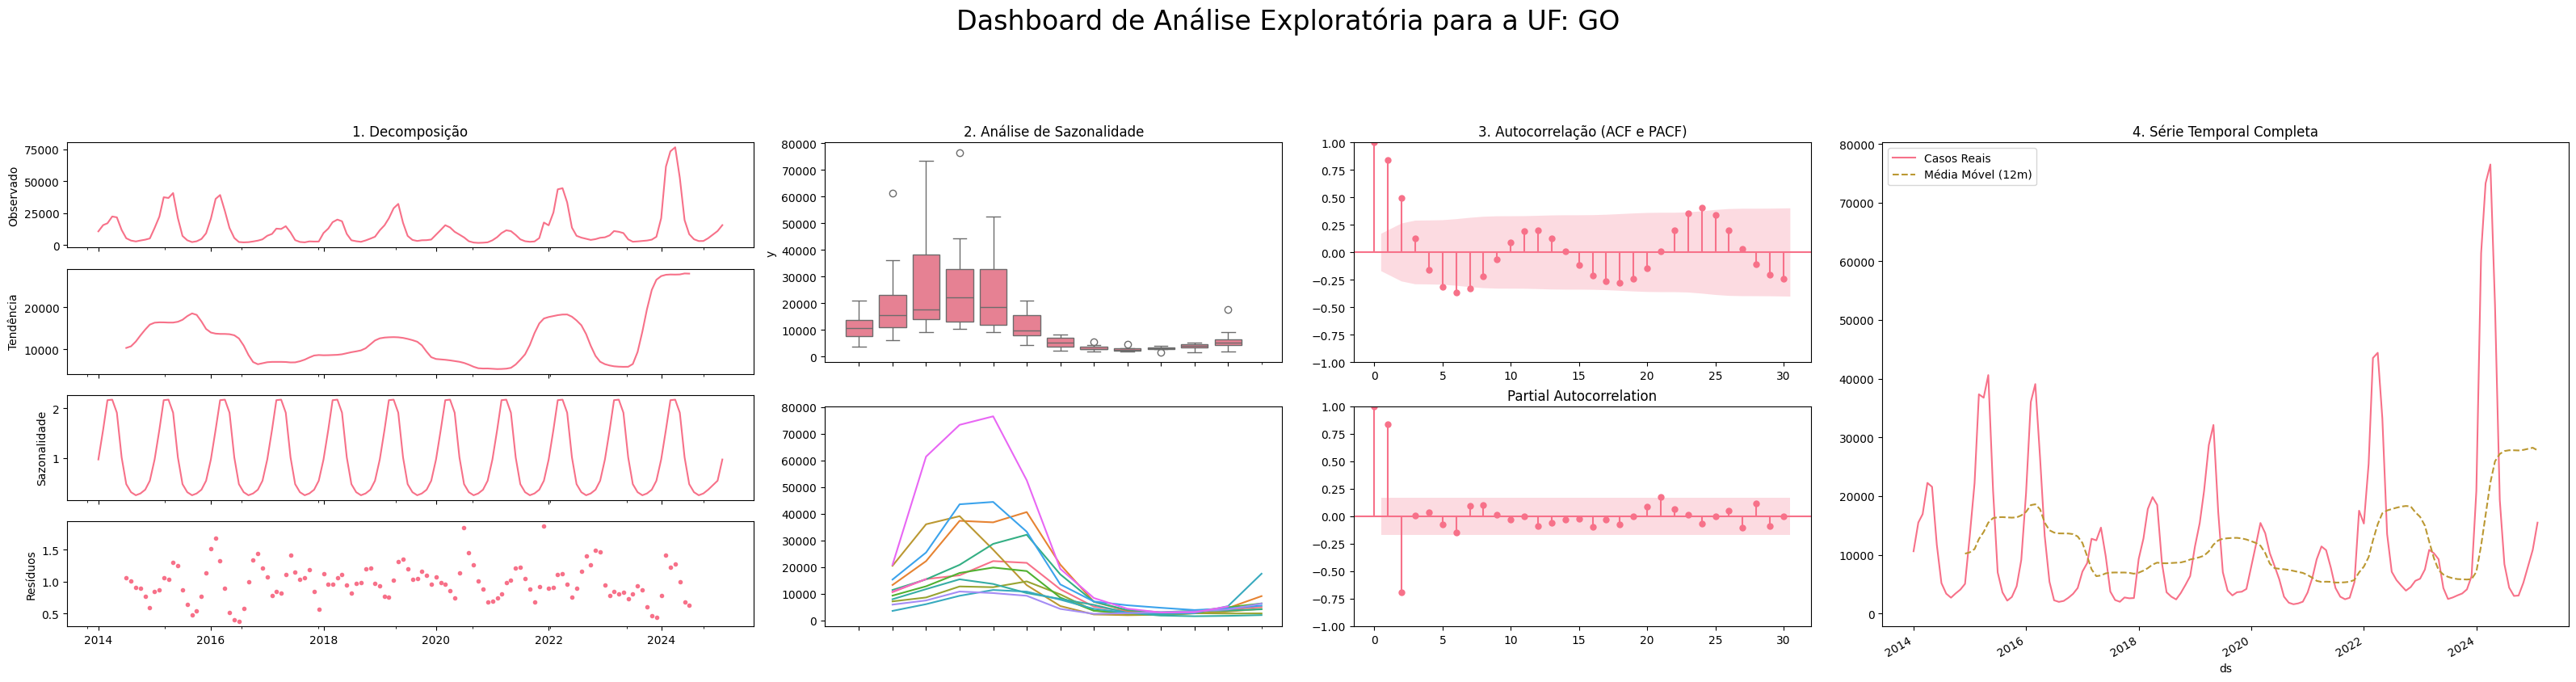

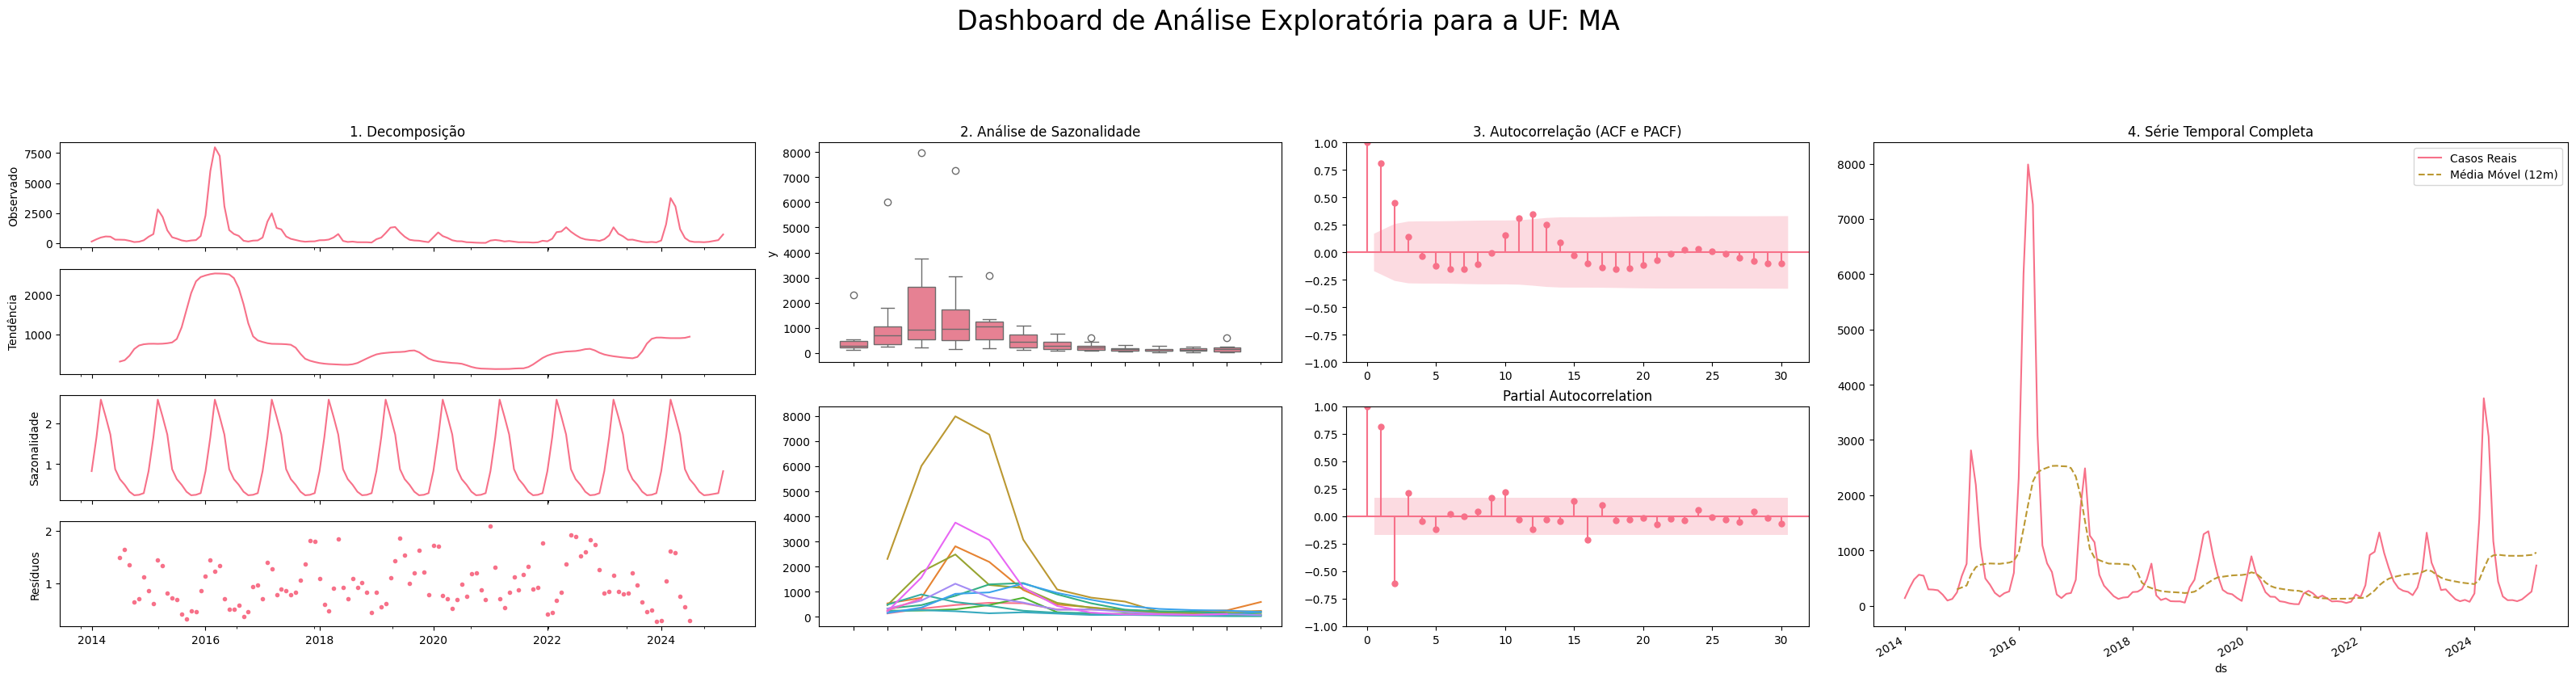

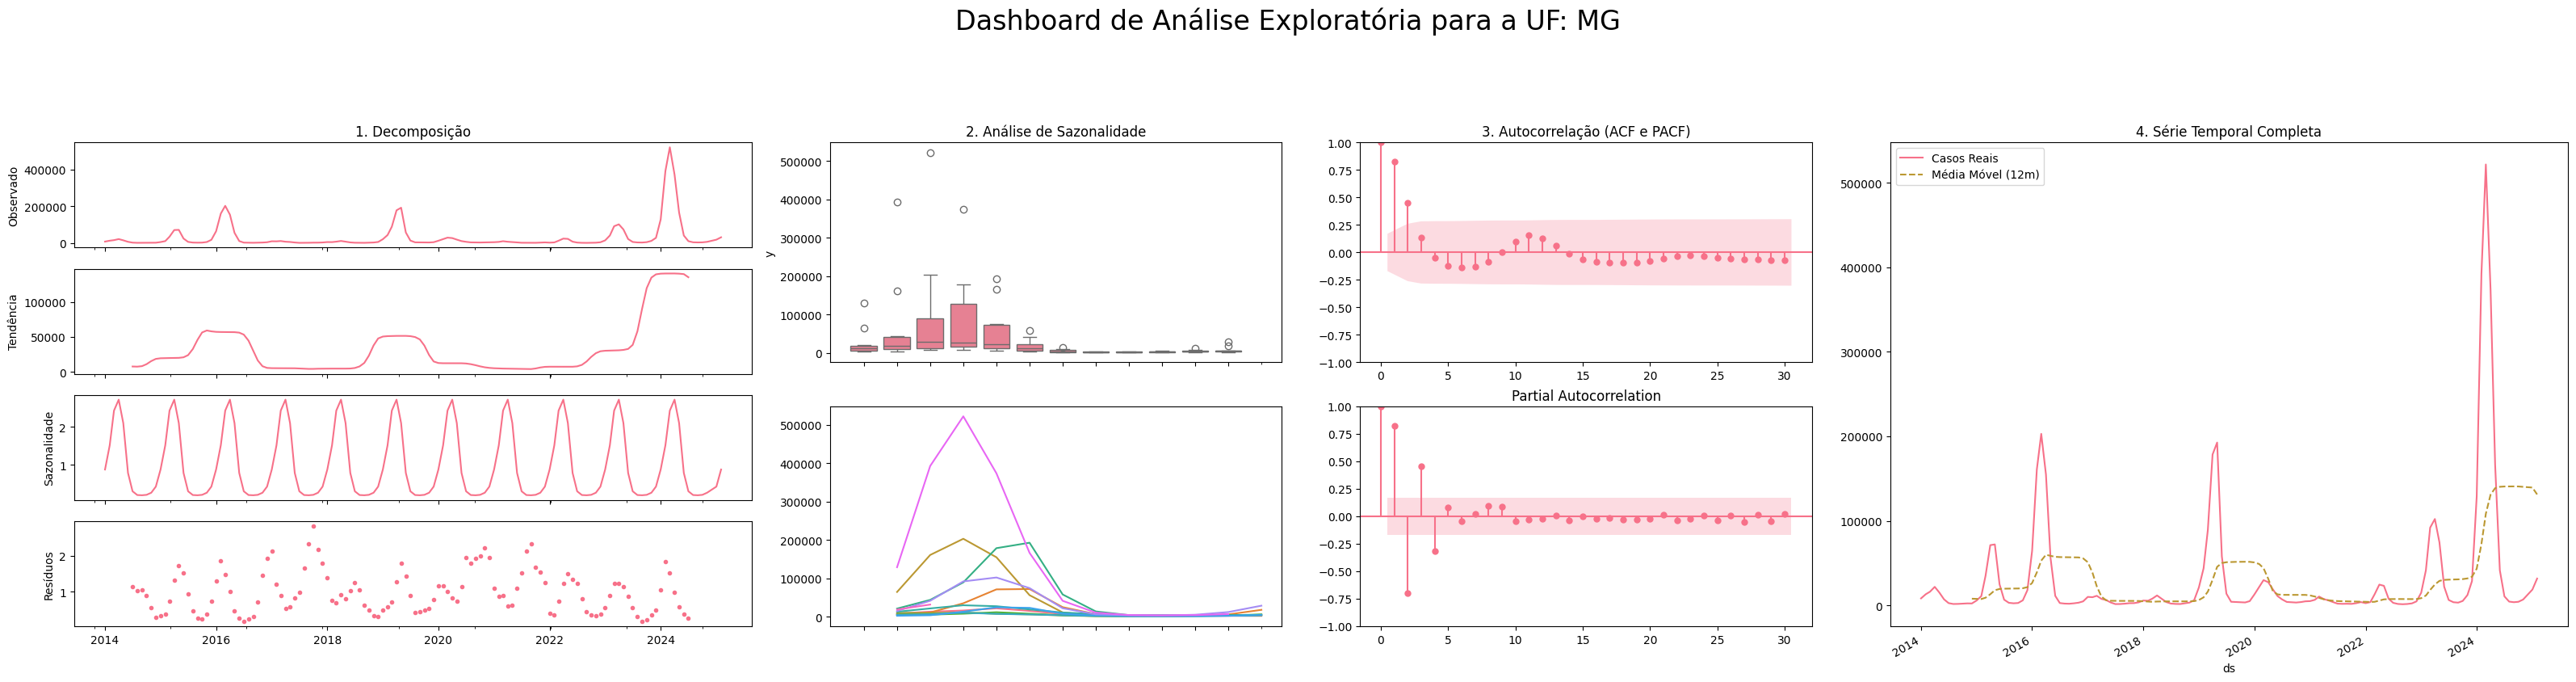

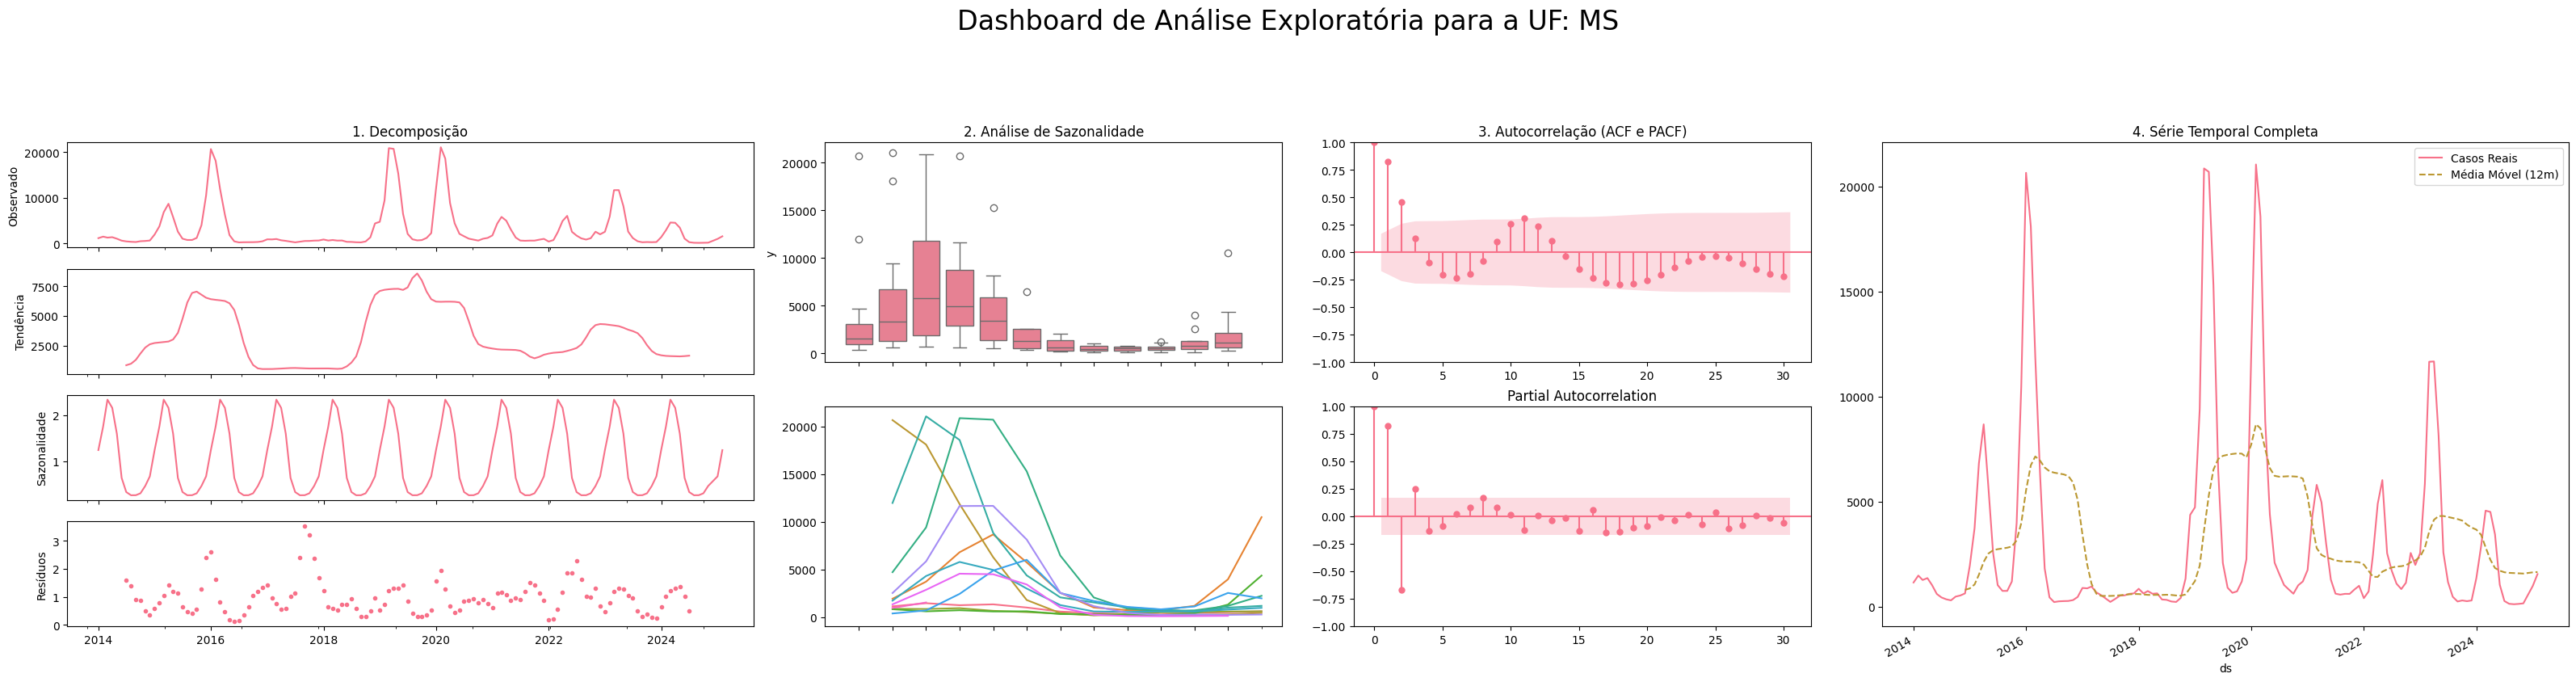

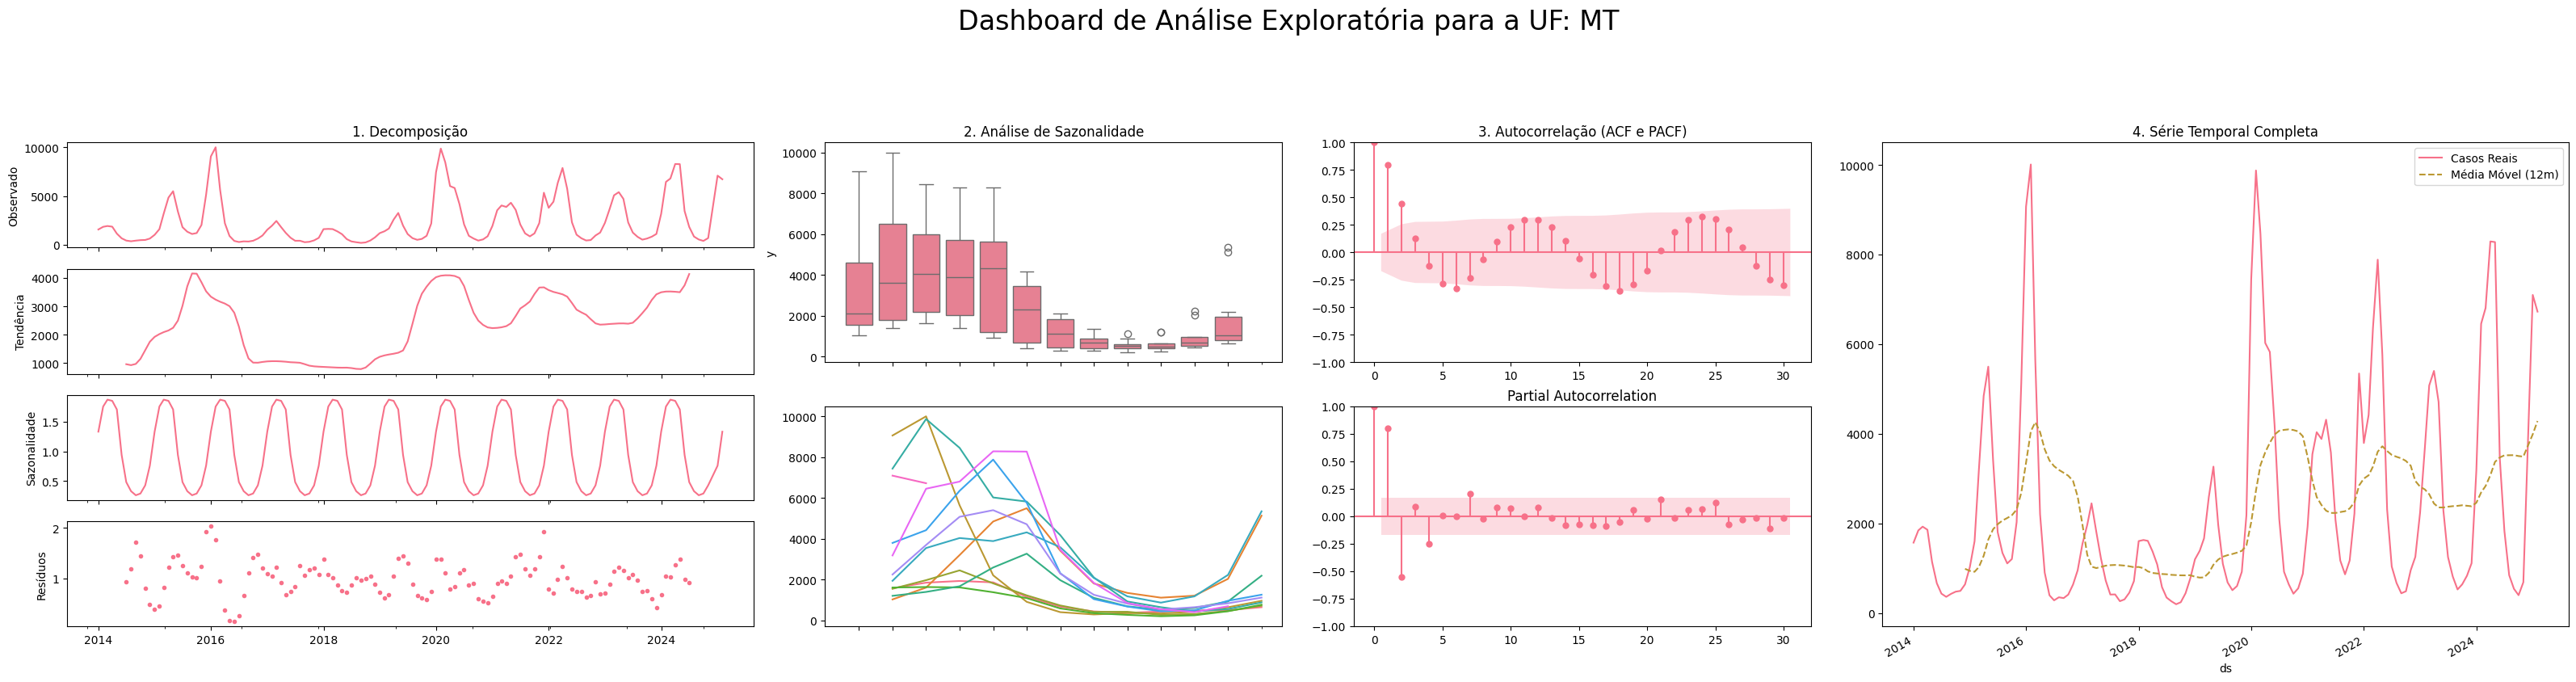

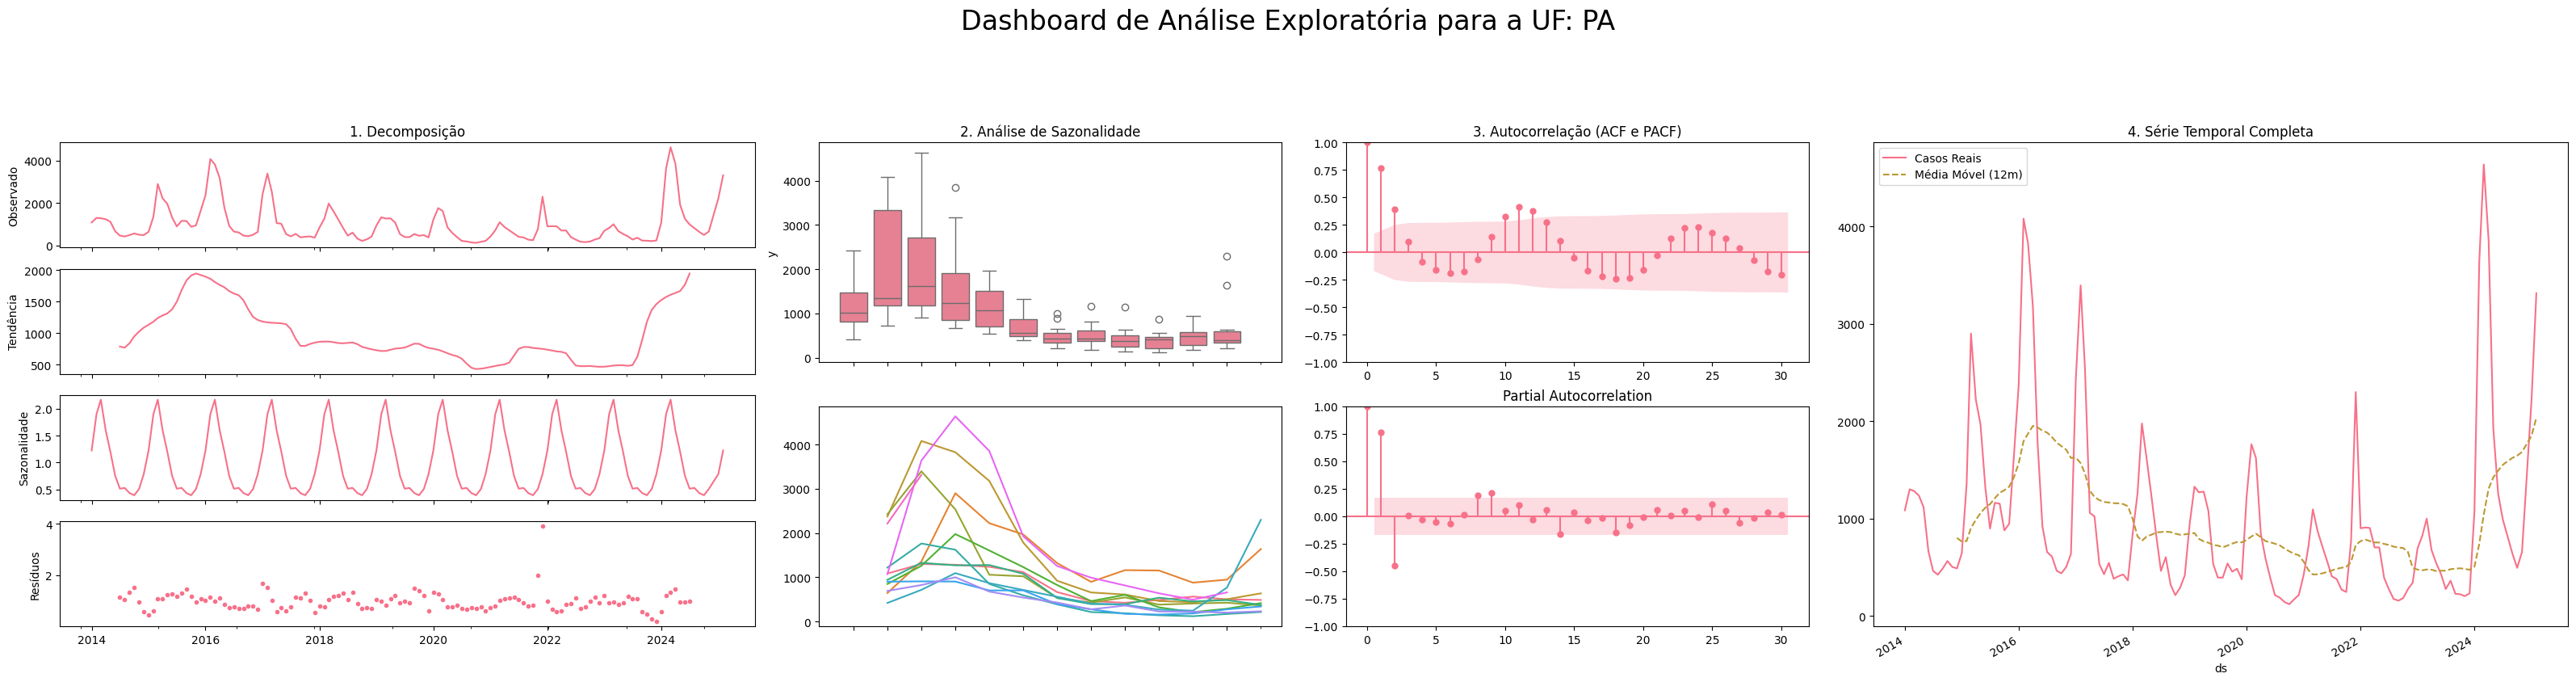

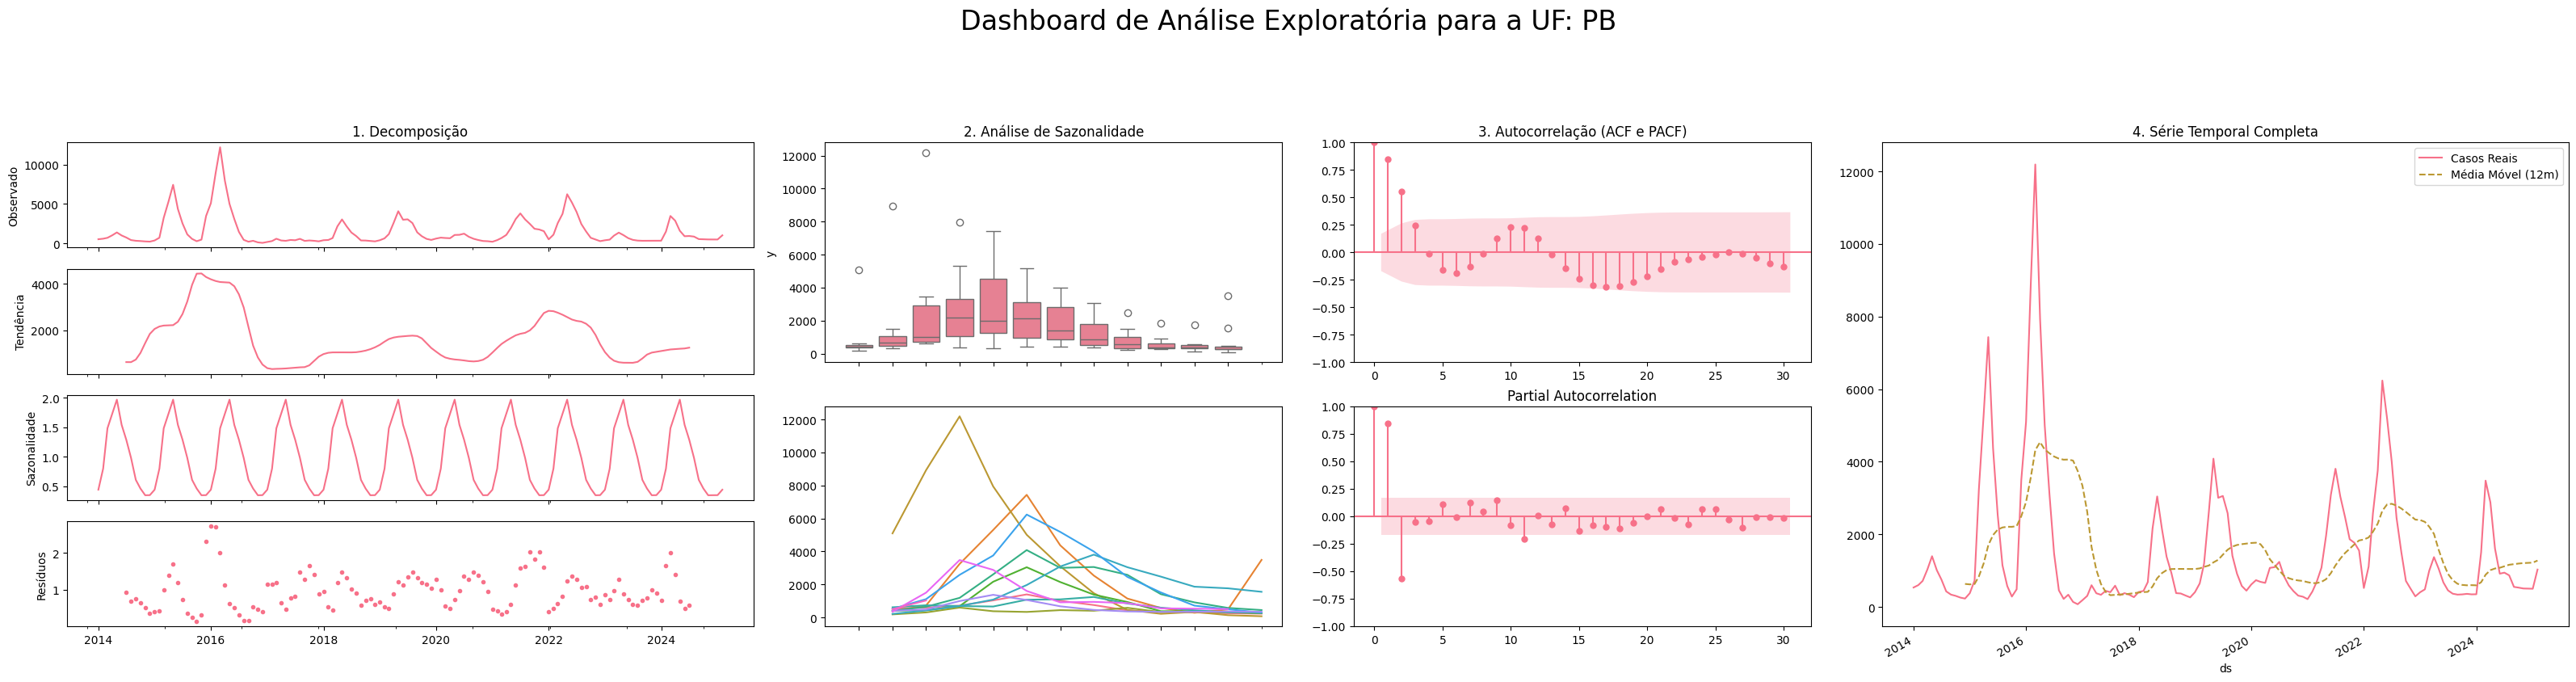

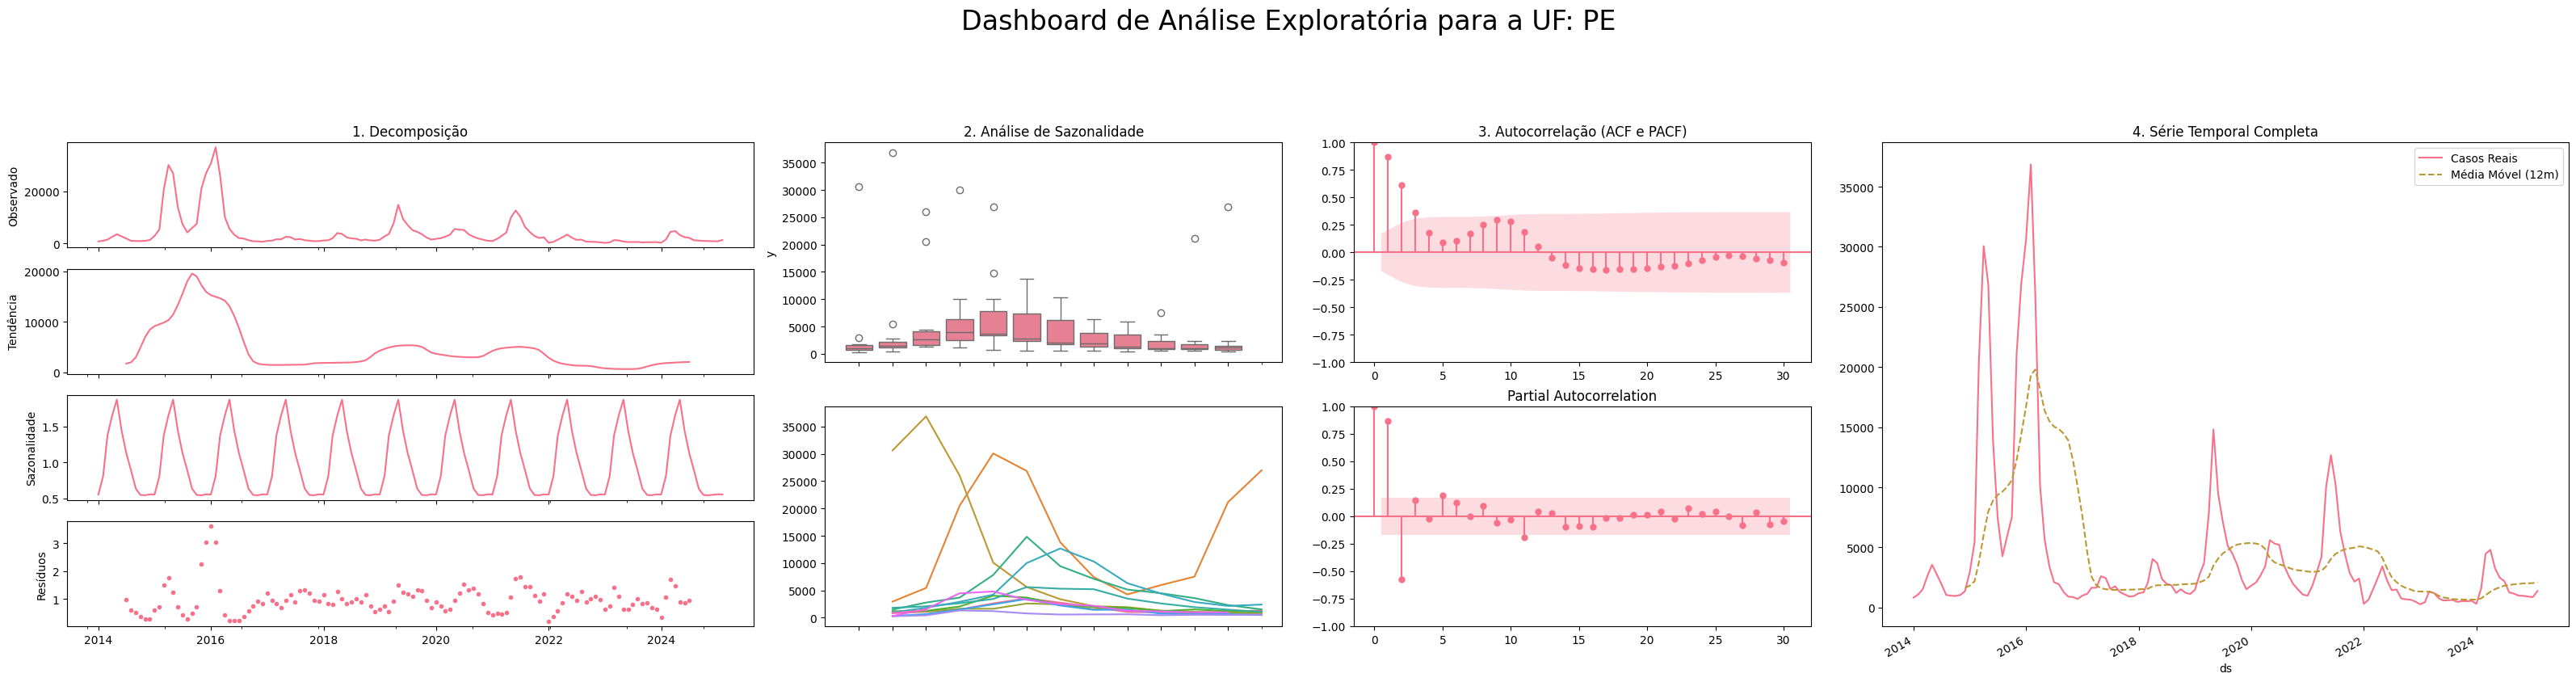

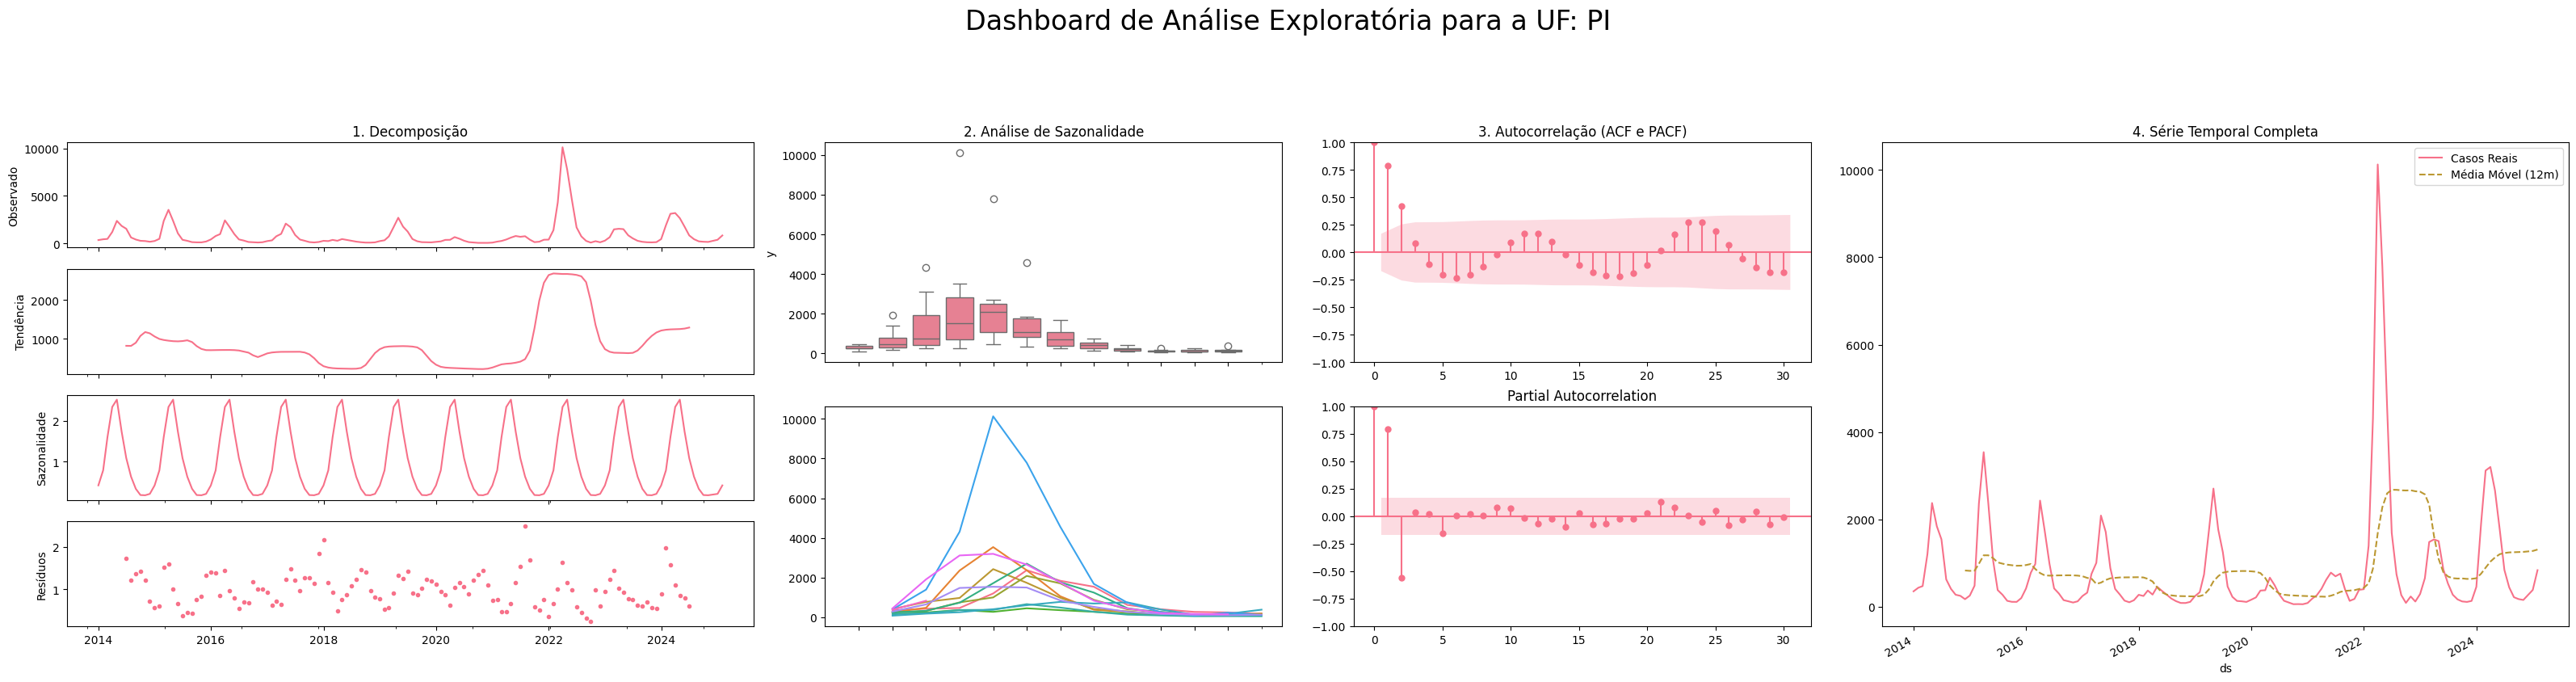

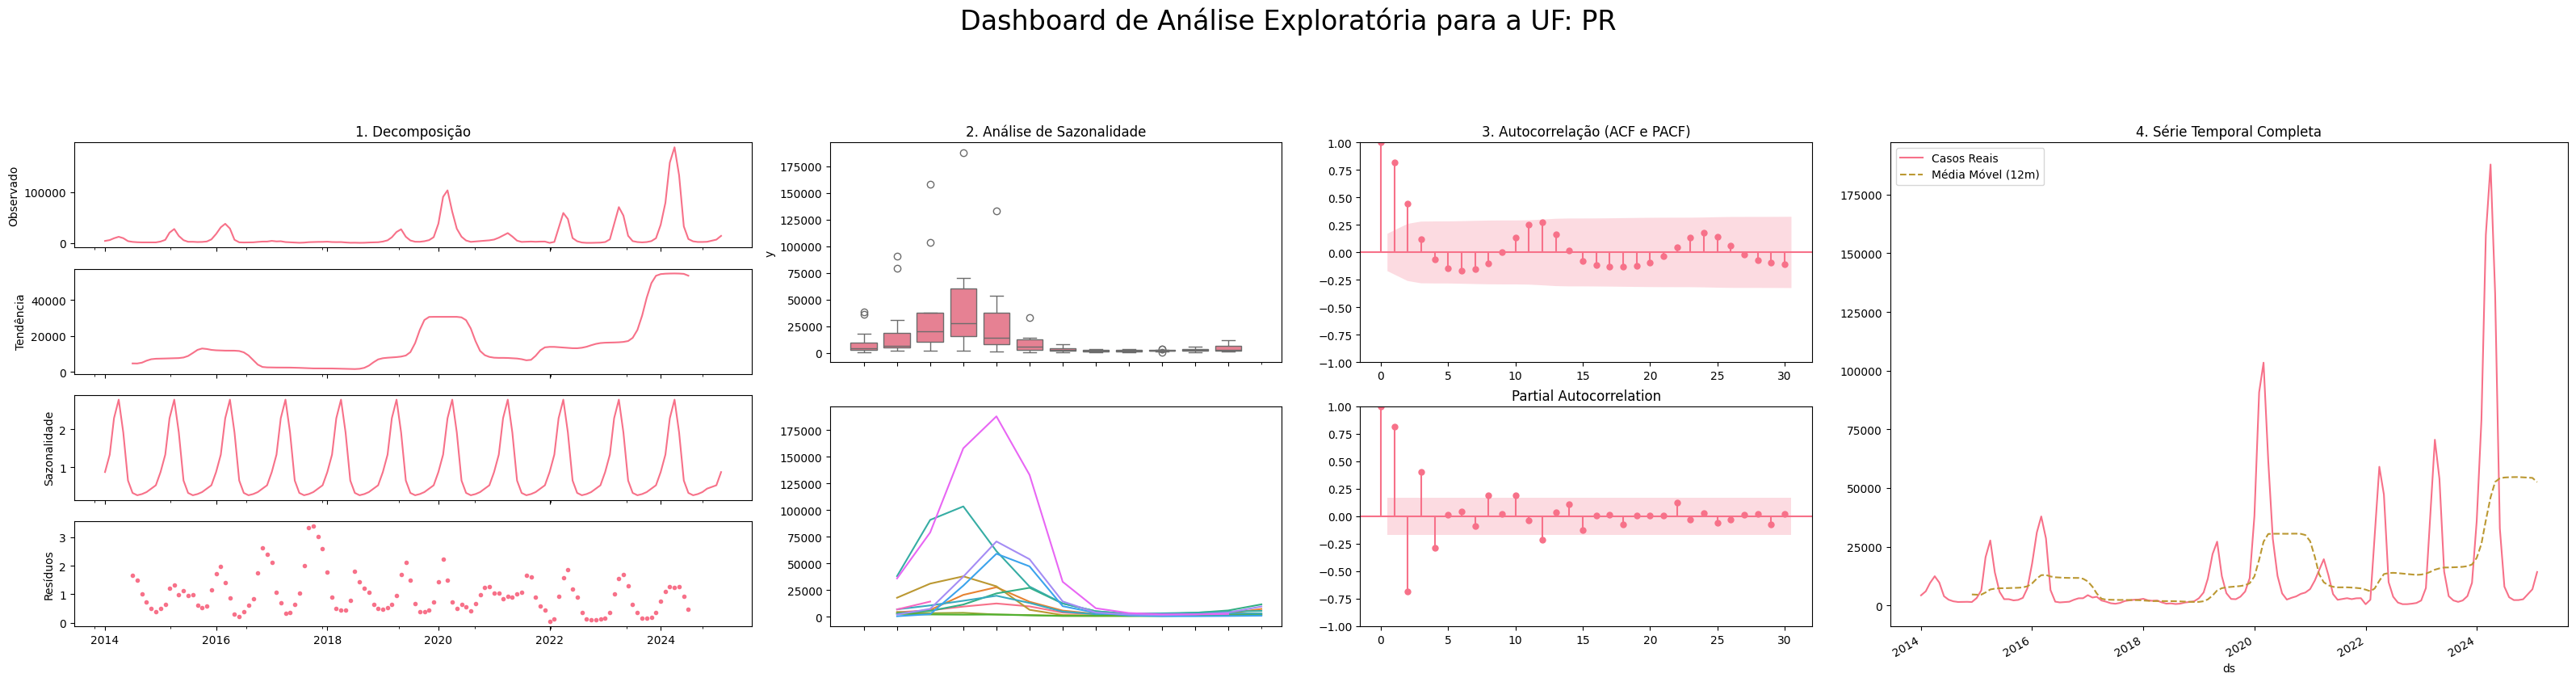

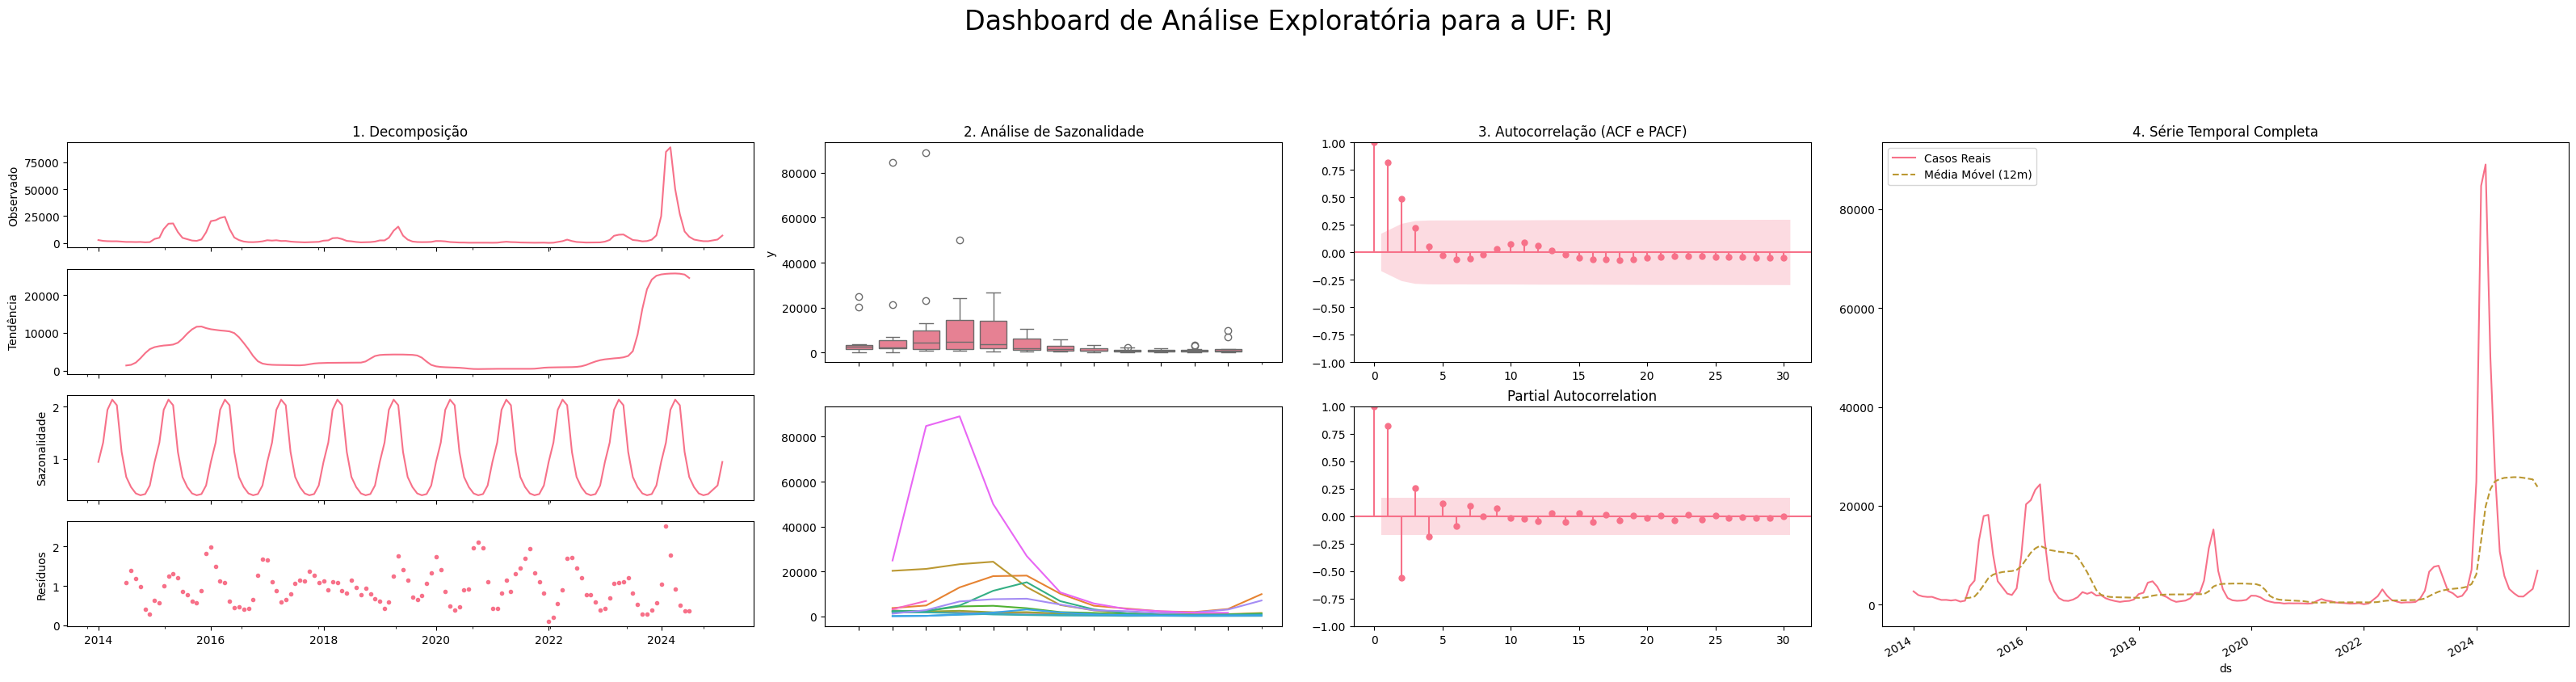

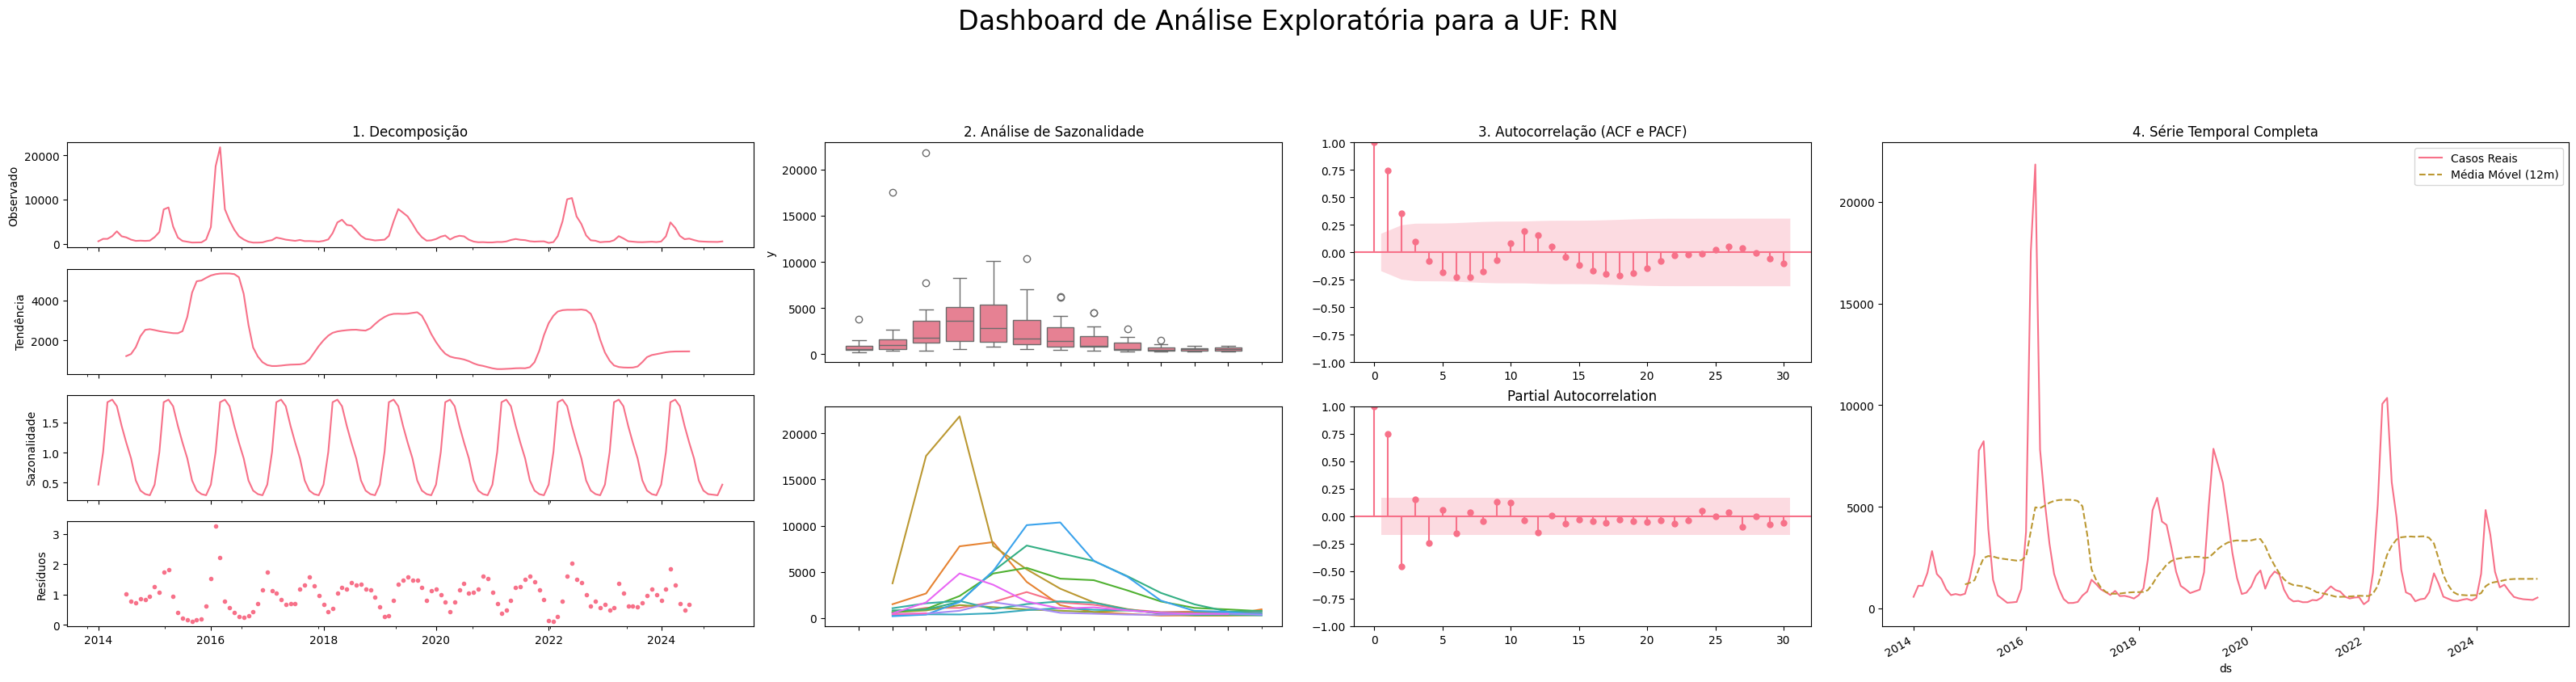

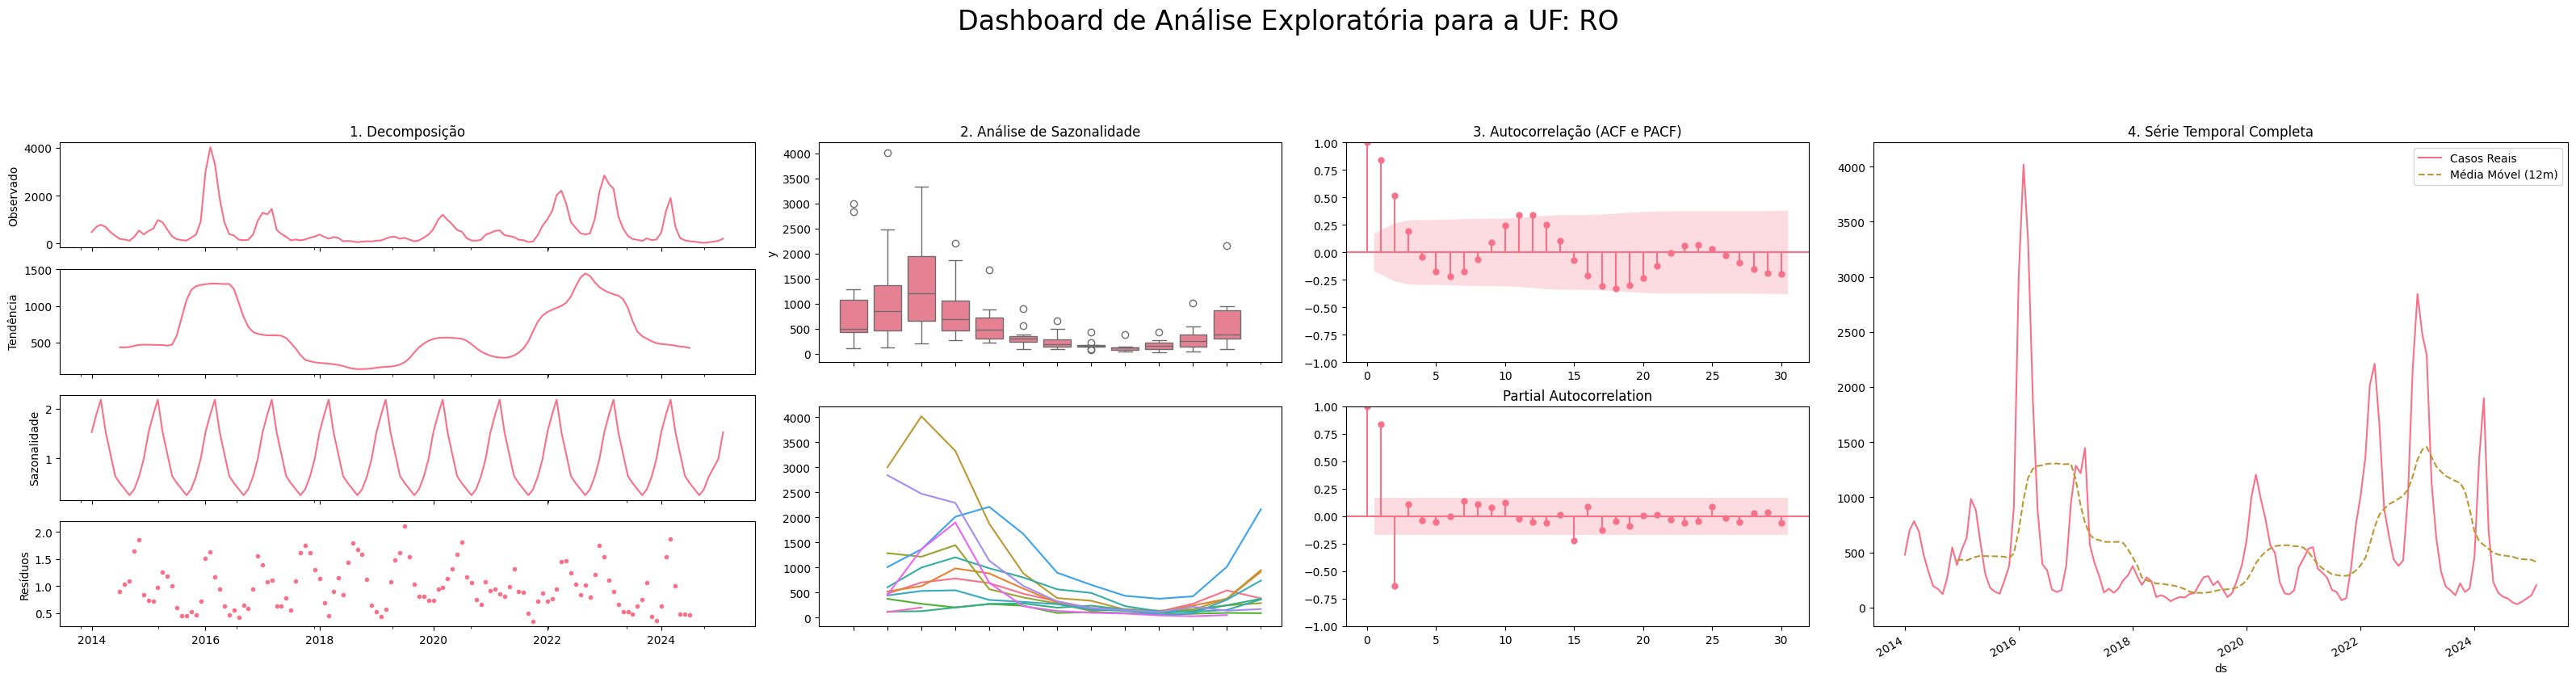

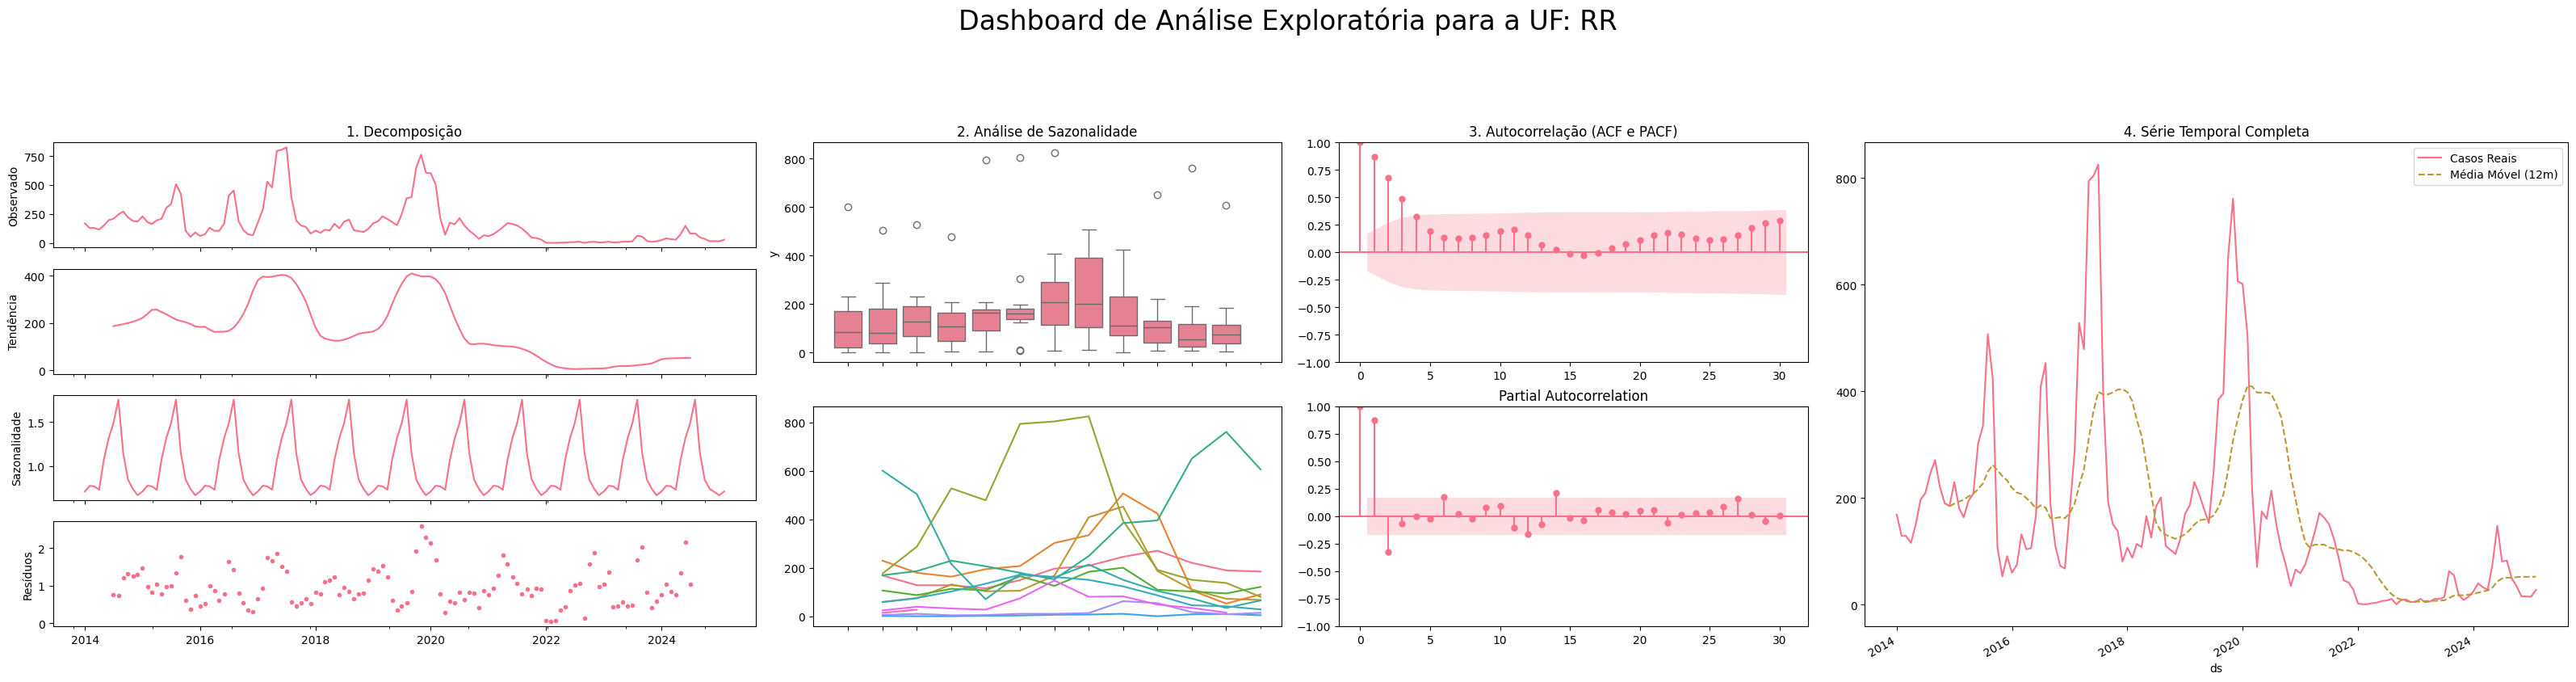

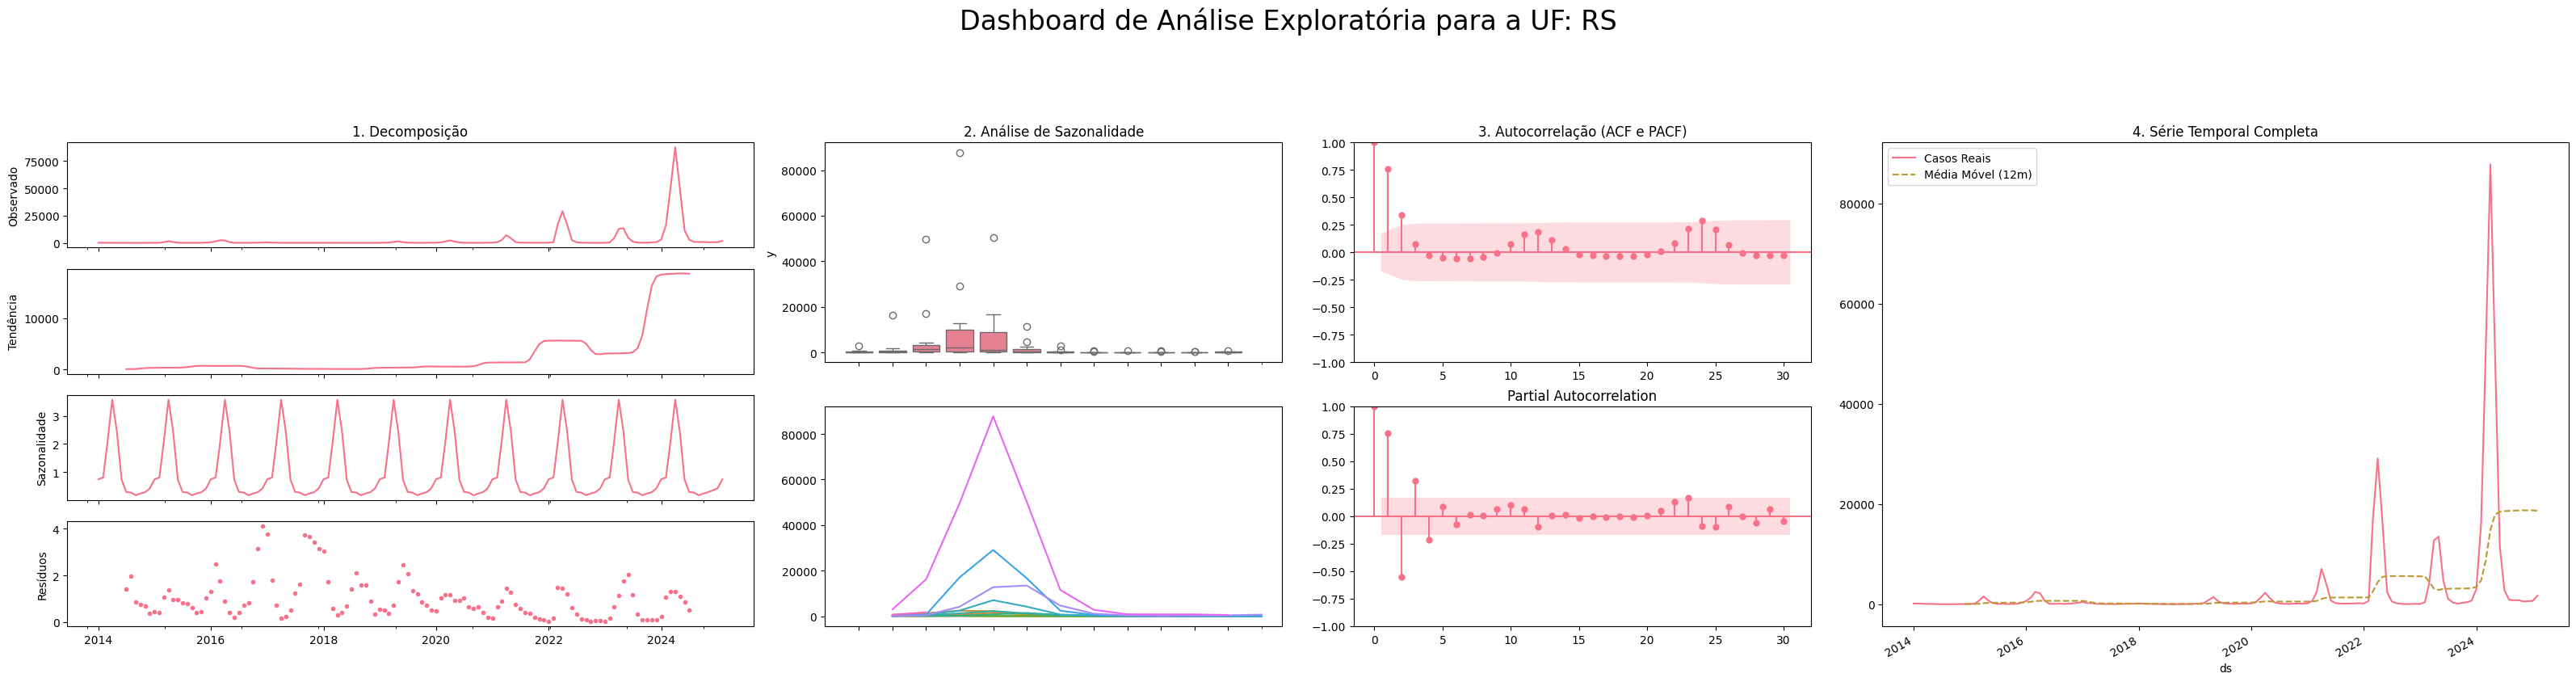

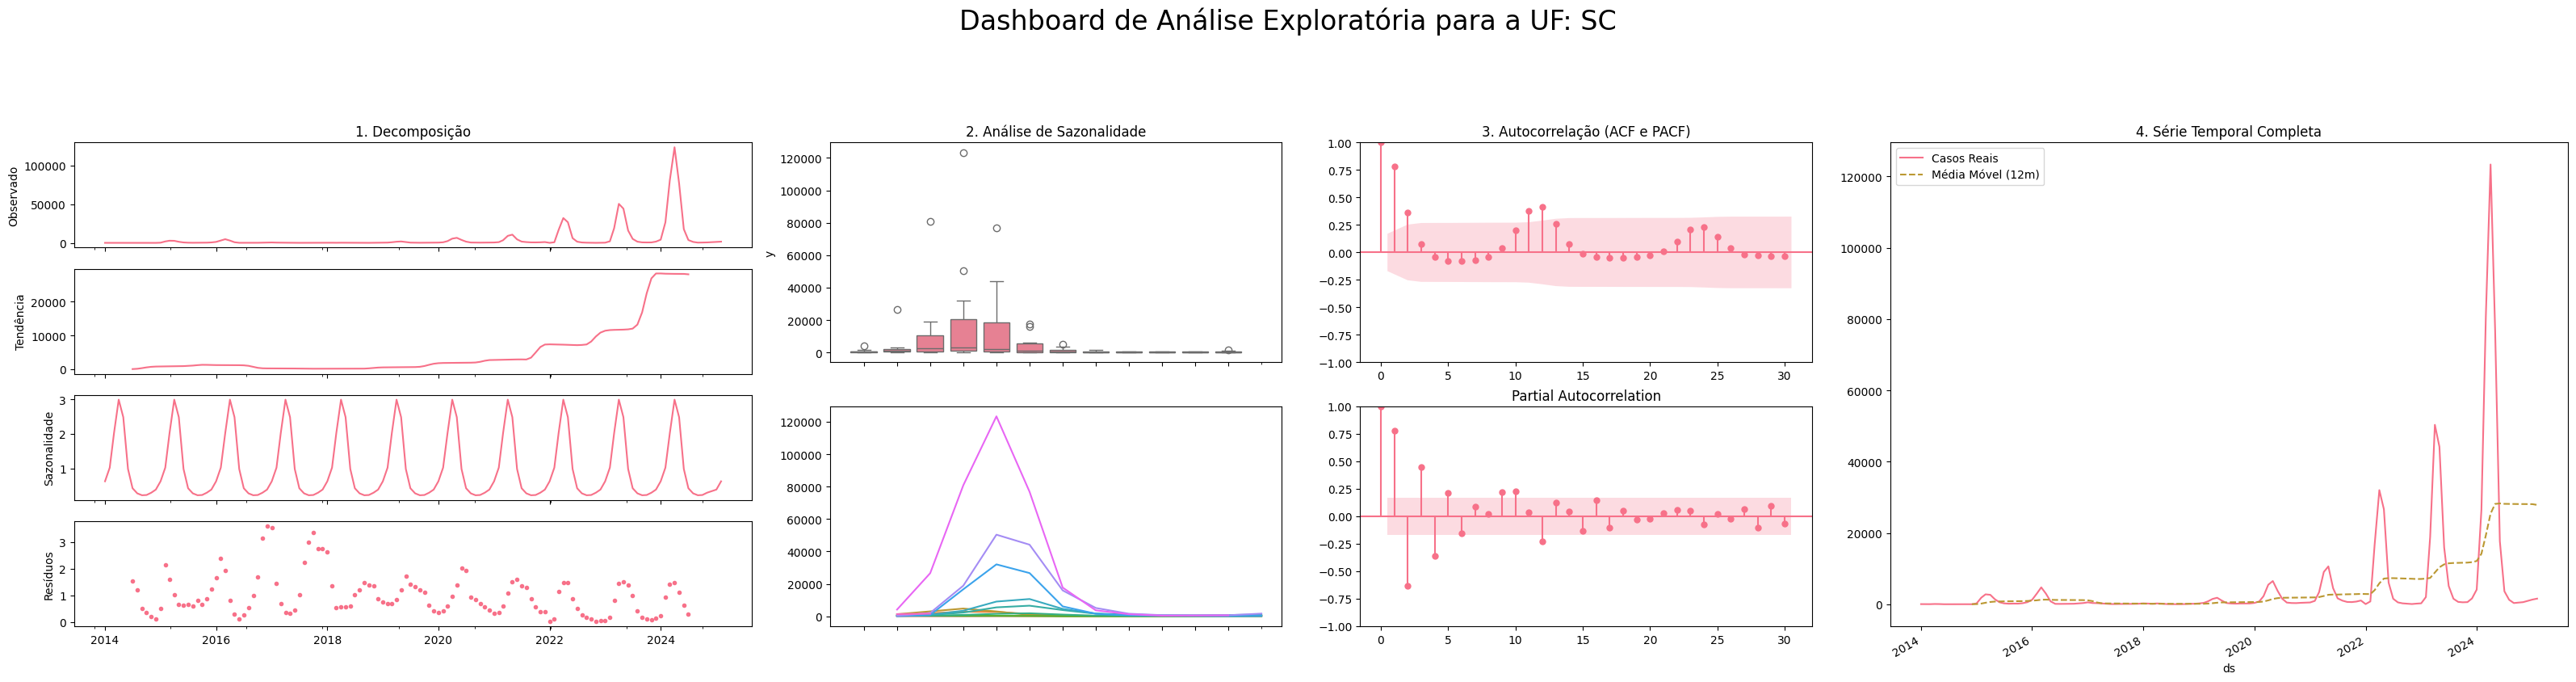

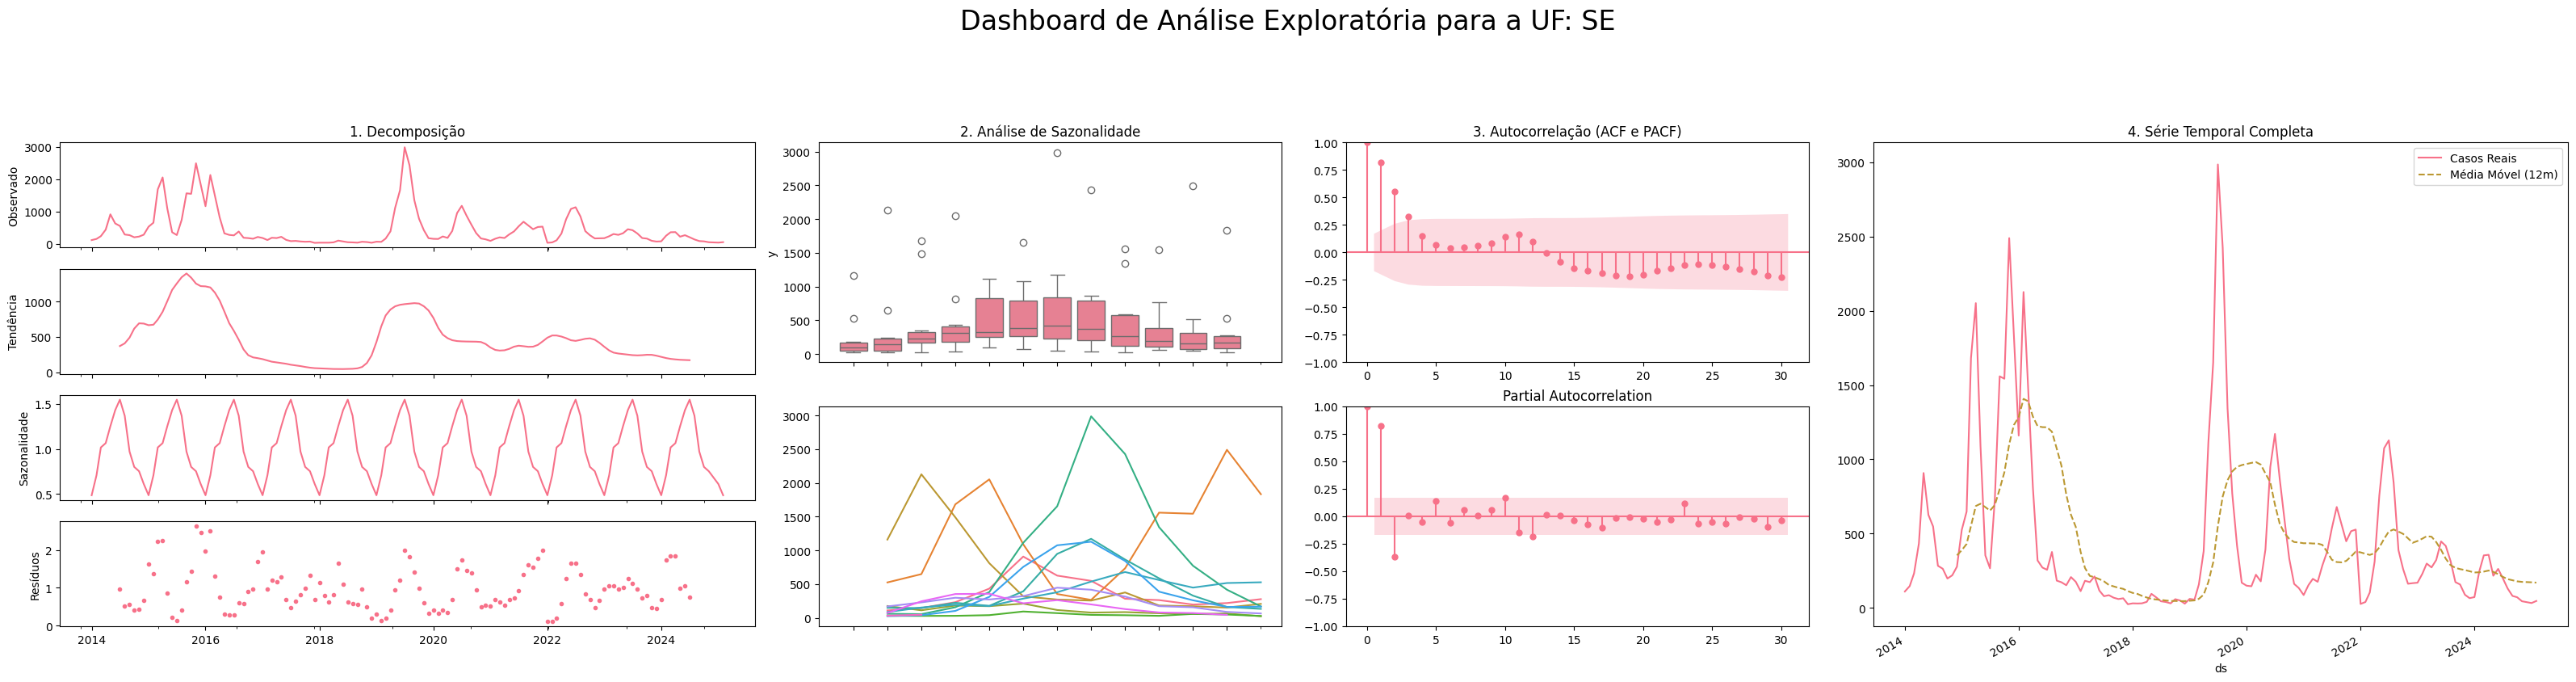

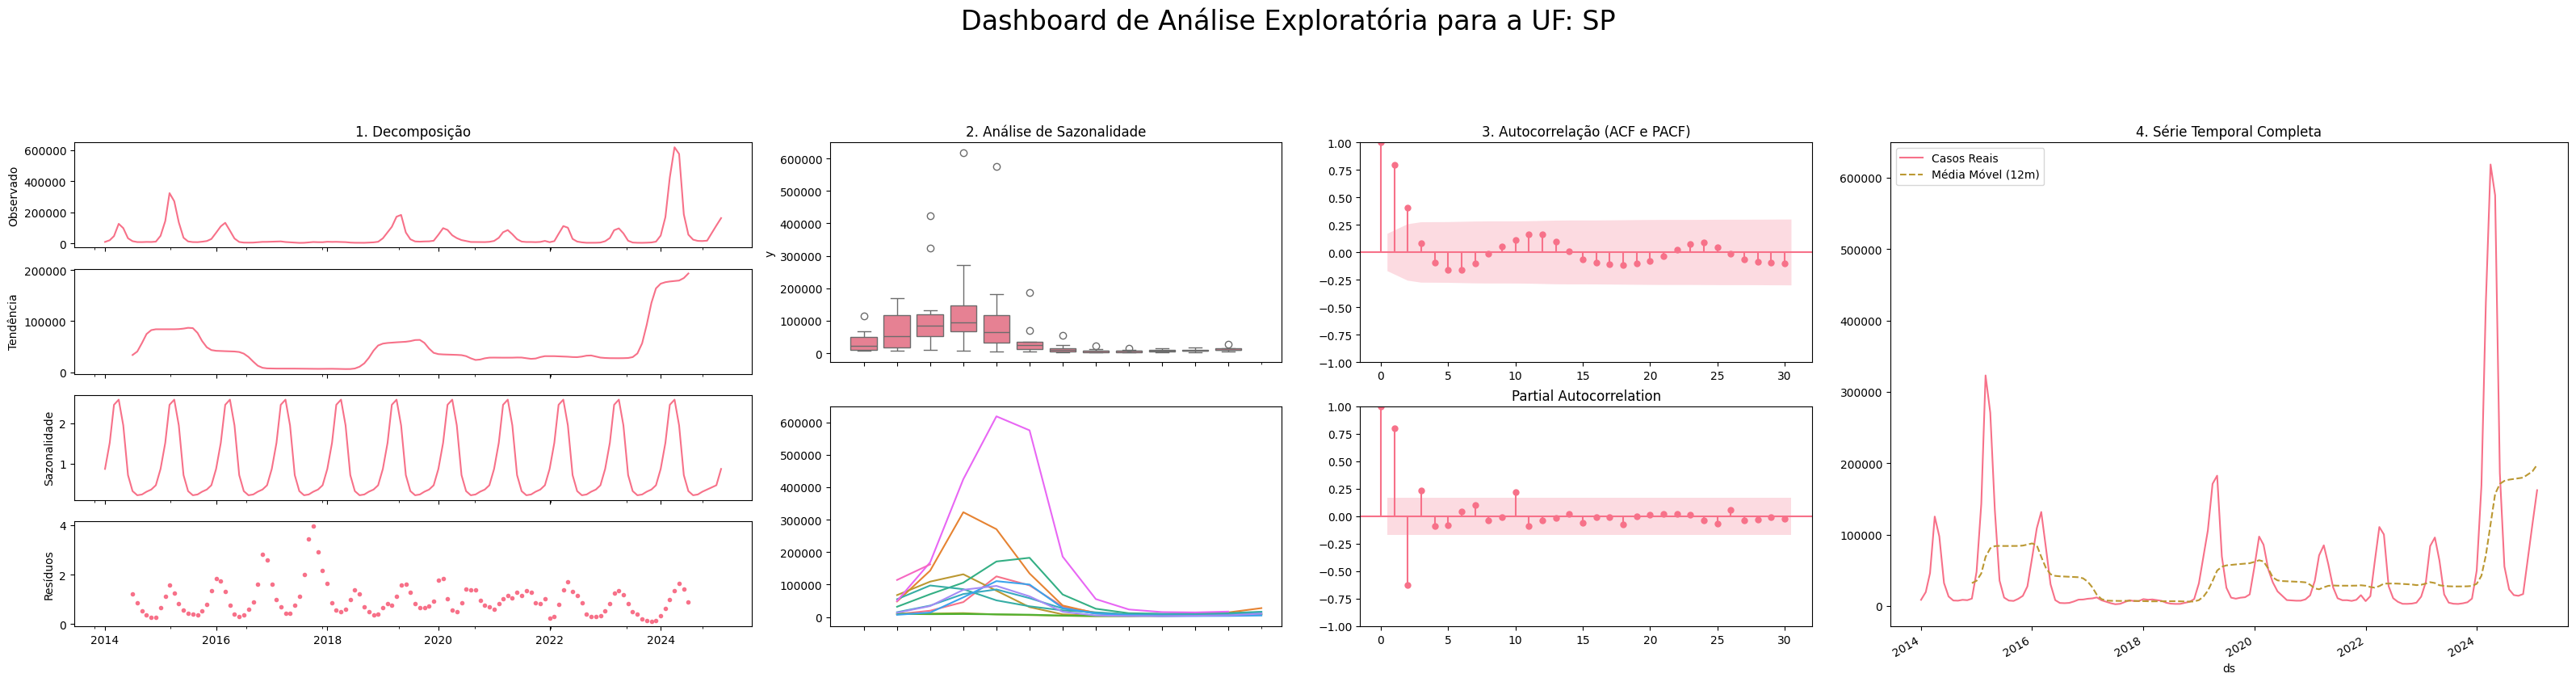

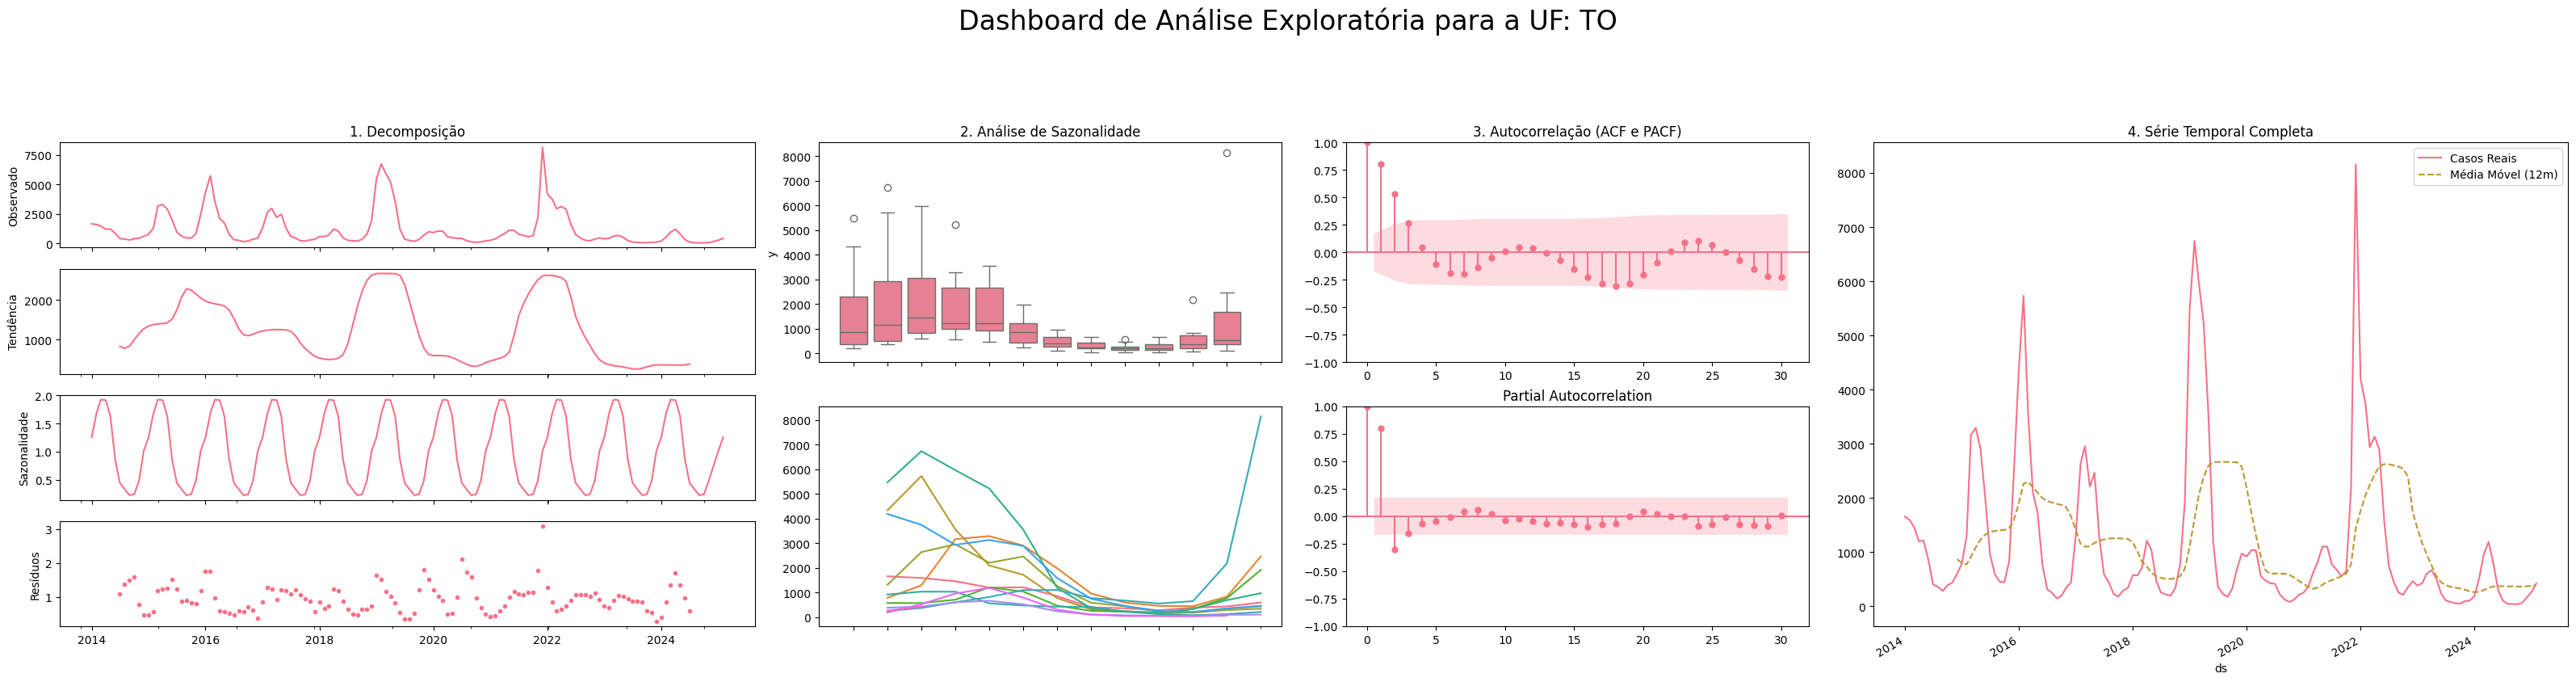

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.gridspec as gridspec

# Itera sobre cada estado no dicionário
for uf, df_estado_original in df_ts_por_estado.items():

    # --- Preparação dos Dados ---
    df_estado = df_estado_original.copy()
    df_estado.set_index('ds', inplace=True)

    # Cria a figura principal
    fig = plt.figure(figsize=(32, 8)) # Aumentei o tamanho para caber tudo
    fig.suptitle(f'Dashboard de Análise Exploratória para a UF: {uf.upper()}', fontsize=24, y=1.05)

    # Cria uma grelha principal de 1 linha e 4 colunas
    gs_main = gridspec.GridSpec(1, 4, figure=fig, width_ratios=[1.5, 1, 1, 1.5])

    # --- Coluna 1: Decomposição da Série Temporal ---
    gs_decompose = gridspec.GridSpecFromSubplotSpec(4, 1, subplot_spec=gs_main[0])
    ax_observed = fig.add_subplot(gs_decompose[0, 0])
    ax_trend = fig.add_subplot(gs_decompose[1, 0], sharex=ax_observed)
    ax_seasonal = fig.add_subplot(gs_decompose[2, 0], sharex=ax_observed)
    ax_resid = fig.add_subplot(gs_decompose[3, 0], sharex=ax_observed)

    try:
        decomposicao = seasonal_decompose(df_estado['y'], model='multiplicative', period=12)
        ax_observed.plot(decomposicao.observed); ax_observed.set_ylabel('Observado'); ax_observed.set_title('1. Decomposição')
        ax_trend.plot(decomposicao.trend); ax_trend.set_ylabel('Tendência')
        ax_seasonal.plot(decomposicao.seasonal); ax_seasonal.set_ylabel('Sazonalidade')
        ax_resid.plot(decomposicao.resid, marker='.', linestyle='none'); ax_resid.set_ylabel('Resíduos')
    except Exception as e:
        ax_observed.text(0.5, 0.5, f'Erro:\n{e}', ha='center', va='center')

    # --- Coluna 2: Análise de Sazonalidade (Boxplot + Ciclo Anual) ---
    gs_seasonal = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_main[1])
    ax_boxplot = fig.add_subplot(gs_seasonal[0, 0])
    ax_cycle = fig.add_subplot(gs_seasonal[1, 0], sharex=ax_boxplot)

    df_estado['Mês'] = df_estado.index.month
    df_estado['Ano'] = df_estado.index.year

    sns.boxplot(x='Mês', y='y', data=df_estado, ax=ax_boxplot)
    ax_boxplot.set_title('2. Análise de Sazonalidade')
    ax_boxplot.set_xlabel('')

    df_pivot = df_estado.pivot_table(values='y', index='Mês', columns='Ano')
    sns.lineplot(data=df_pivot, dashes=False, legend=False, ax=ax_cycle)
    ax_cycle.set_xlabel('Mês do Ano')

    # --- Coluna 3: Análise de Autocorrelação (ACF + PACF) ---
    gs_corr = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_main[2])
    ax_acf = fig.add_subplot(gs_corr[0, 0])
    ax_pacf = fig.add_subplot(gs_corr[1, 0])

    nlags_seguro = min(30, len(df_estado['y']) // 2 - 1)

    plot_acf(df_estado['y'], lags=nlags_seguro, ax=ax_acf)
    ax_acf.set_title('3. Autocorrelação (ACF e PACF)')

    plot_pacf(df_estado['y'], lags=nlags_seguro, ax=ax_pacf)

    # --- Coluna 4: Visualização da Série Completa ---
    ax_serie = fig.add_subplot(gs_main[3])
    ax_serie.plot(df_estado.index, df_estado['y'], label='Casos Reais')
    # Adiciona uma média móvel para visualizar a tendência de forma suave
    df_estado['y'].rolling(window=12).mean().plot(ax=ax_serie, linestyle='--', label='Média Móvel (12m)')
    ax_serie.set_title('4. Série Temporal Completa')
    ax_serie.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## 📋 Conclusões da Análise Inicial

**Principais insights encontrados:**

✅ **Estrutura dos Dados:**
- Dataset estruturado em formato CSV com 3.536 registros
- Período: 2014-2025 (dados mensais por estado)
- Sem valores ausentes
- Variáveis climáticas e de saneamento disponíveis

✅ **Padrões Temporais:**
- Sazonalidade clara nos casos de dengue
- Picos geralmente nos primeiros meses do ano
- Variação significativa entre anos

✅ **Distribuição Geográfica:**
- Concentração de casos em alguns estados específicos
- Necessidade de trabalhar em nível municipal (próximo passo)

✅ **Relações com Clima:**
- Correlações identificadas entre variáveis climáticas e casos
- Temperatura e umidade parecem influenciar nos casos

**Próximos Passos:**
1. Processamento e enriquecimento dos dados
2. Criação de features de lag e médias móveis
3. Desenvolvimento dos modelos de ML